dodgerblue, tomato, red, brown, darkblue, lightblue

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
import torch
from scipy.integrate import solve_ivp
from collections.abc import Callable
from typing import Tuple

WIDTH = 6.92
HEIGHT = 4.2

def set_pubstyle(fontsize=10, font_family='serif', usetex=False):
    plt.rcParams.update({
        "font.size": fontsize,
        "font.family": font_family,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize + 1,
        "legend.fontsize": fontsize - 1,
        "xtick.labelsize": fontsize - 1,
        "ytick.labelsize": fontsize - 1,
        "figure.titlesize": fontsize + 2,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "lines.linewidth": 1.6,
        "axes.linewidth": 0.8,
        "grid.alpha": 0.2,
        "figure.figsize": (WIDTH, HEIGHT),
    })
    if usetex:
        plt.rcParams.update({"text.usetex": True})

# Call once globally for consistent style
set_pubstyle(fontsize=10, font_family='serif', usetex=False)

Helper functions

In [2]:
# Helper: wrap a PyTorch model that takes a torch tensor of shape (N,) or (N,1)
def make_torch_wrapper(pt_model, device="cpu", batch_dim=False):
    """
    Wrap a PyTorch model so it can be called as a numpy function u -> out (numpy array).
    - pt_model should accept a torch tensor of shape (N,) or (N,1) and return (N,) or (N,1)
    - device: 'cpu' or 'cuda'
    - batch_dim: if True, the model expects input shape (batch, N) or similar; keep False for elementwise
    Returns: callable(u_numpy) -> numpy array
    """
    pt_model.to(device)
    pt_model.eval()
    def wrapper(u_np: np.ndarray) -> np.ndarray:
        # Convert to torch tensor
        with torch.no_grad():
            u_t = torch.from_numpy(u_np.astype(np.float32)).to(device)
            # If model expects shape (N,1), reshape
            if u_t.ndim == 1:
                u_t_in = u_t.unsqueeze(1)  # (N,1)
            else:
                u_t_in = u_t
            out = pt_model(u_t_in)
            # If out has shape (N,1) or (N,), convert to 1D numpy
            out_np = out.detach().cpu().numpy()
            out_np = out_np.reshape(u_np.shape)
        return out_np
    return wrapper

# reconstruct the solution using the learned NN 'D_model' at the training points (x_train, t_train)
def recon_solution(x_train, t_train, D_model, u_true_IC):
    D_callable = make_torch_wrapper(D_model, device='cpu')
    u_sim = simulate_pde(x_train, u_true_IC, D_callable,
                       t_span=(t_train[0], t_train[-1]),
                       t_eval=t_train,
                       integrator="RK45")
    return u_sim

# Simulate the PDE u_t = (D(u) u_x)_x with Neumann BCs using method of lines and solve_ivp
def simulate_pde(x: np.ndarray,
                 IC: np.ndarray,
                 D_callable: Callable[[np.ndarray], np.ndarray],
                 t_span: Tuple[float, float] = (0.0, 20.0),
                 t_eval: np.ndarray = None,
                 integrator: str = "RK45",
                 rtol: float = 1e-6,
                 atol: float = 1e-8,
                 save_path: str = None):
    """
    Simulate FKPP with BC: u_x=0 at boundaries (note: not no-flux BCs!).
    Inputs:
      x           : 1D grid (numpy array)
      IC          : initial condition (numpy array same length as x)
      D_callable  : function(u_array) -> D_array (same length as u)
      t_span      : (t0, tf)
      t_eval      : times to evaluate solution; default 201 points between t0 and tf
      integrator  : "RK45" or "BDF" etc; BDF recommended if stiff
      rtol, atol  : tolerances for solve_ivp
      save_path   : optional path to save final u as npy
    Returns:
      sol : the SciPy OdeResult-like object from solve_ivp (sol.y shape (N, len(t_eval)))
    """
    
    x = np.asarray(x)
    N = x.size
    dx = x[1] - x[0]
    assert IC.shape == x.shape, "IC must match x shape"
    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 201)

    def rhs(t, u_vec):
        u = np.asarray(u_vec)

        # Evaluate D at nodes
        Dn = D_callable(u)
        if Dn.shape != u.shape:
            raise ValueError("D_callable must return array of same shape as u")

        # Build ghost-point extension for Neumann BCs: u_x = 0
        u_ext = np.empty(N + 2, dtype=u.dtype)
        u_ext[1:-1] = u
        u_ext[0] = u[1]      # left ghost cell: u_{-1} = u_1
        u_ext[-1] = u[-2]    # right ghost cell: u_N = u_{N-2}

        # Extend D consistently
        Dn_ext = np.empty(N + 2, dtype=Dn.dtype)
        Dn_ext[1:-1] = Dn
        Dn_ext[0] = Dn[1]
        Dn_ext[-1] = Dn[-2]

        # D at interfaces
        D_half = 0.5 * (Dn_ext[:-1] + Dn_ext[1:])   # length N+1

        # Fluxes at interfaces
        flux = D_half * (u_ext[1:] - u_ext[:-1]) / dx   # length N+1

        # Divergence at physical nodes
        diffusion_term = (flux[1:] - flux[:-1]) / dx

        return diffusion_term
        
    sol = solve_ivp(rhs, t_span, IC, method=integrator, t_eval=t_eval, rtol=rtol, atol=atol)

    if not sol.success:
        print("Warning: solver reported failure:", sol.message)
    if save_path is not None:
        np.save(save_path, sol.y[:, -1])
        print(f"Saved final state to {save_path}")

    return sol.y.T


Plot formatting & setups

In [3]:
# plot formatting
# plt.rcParams['font.family'] = 'overall_overall_times New Roman'
# plt.rcParams['text.usetex'] = True
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['axes.labelweight'] = 'bold'  # Bold axis labels
# plt.rcParams['axes.titleweight'] = 'bold'  # Bold title
# plt.rcParams['font.weight'] = 'bold'
# plt.rcParams['font.size'] = str(20)
# plt.rcParams['lines.linewidth'] = 2

# epochs for training history
epoch_hist = np.arange(0, 4001, 1)

# time resolutions
Nt, t_end, t_min = 7, 18, 0.0
t_train = np.linspace(t_min, t_end, Nt)

# spatial resolutions
L = 7.0
x_min, x_max = -L, L
dx_long = 0.04
x_train = np.arange(x_min, x_max+dx_long, dx_long)
Nx = len(x_train)

# true solutions
D_true = 0.5 # true diffusivity
xx, tt = np.meshgrid(x_train, t_train)
u_true = 0.5 * np.cos(np.pi * xx / L) * np.exp(-tt * D_true * (np.pi**2) / (L**2)) + 0.5 # so that u in [0, 1]
u_min_np, u_max_np = u_true.min(), u_true.max()
U_grid= np.linspace(u_min_np, u_max_np, Nx)

# the variances we used 
variances = [0, 1e-3, 5e-3, 1e-2, 5e-2]
seed = 8

NumRep = 10

top_load_folder = '../ARCresults/Diffusion_linear/'
top_save_folder = '../Figures/Fig2/'


u_structs = [r'$(4, 32)$', r'$(6, 128)$']

Loop through variances to store the L2RE of u_NN and u_reconstr

In [4]:
subfolders = ['additive_noise_seed8_uStruct4_32/', 'additive_noise_seed8_uStruct6_128/']

In [4]:

# Initialise arrays to store u_reconstr, and the L2REs of u_NN and u_reconstr
errorS_uNN, errorS_u_reconstr, u_pred_all = [[], []], [[], []], [[], []]
for s in range(len(subfolders)):
    for n in range(len(variances)):
        errorS_u_reconstr[s].append([])
        u_pred_all[s].append([])
        errorS_uNN[s].append([])


for n, var in enumerate(variances):

    noise = np.sqrt(var)

    for s in range(len(subfolders)):
        subfolder = subfolders[s]
    
        np.random.seed(seed)
        u_true_noisy = u_true.copy() + noise * np.random.randn(*np.shape(u_true))

        for rep in range(NumRep):
            # load the best D_model for this variance and this repetition
            D_model = torch.load(top_load_folder + subfolder + f'var{var}/Iter{rep}/D_net_best_Iter{rep}.pth', map_location=torch.device('cpu'), weights_only=False)

            # ------------------ YY -----------------
            # use the learnt u_NN at t=0 as the initial condition to reconstruct the solution using the learned D_model
            fullgrid_u_NN = np.load(top_load_folder + subfolder + f'var{var}/Iter{rep}/fullgrid_u_pred.npy')
            fullgrid_u_NN_IC = fullgrid_u_NN[0, :]
            u_sim = recon_solution(x_train, t_train, D_model, fullgrid_u_NN_IC)
            u_pred_all[s][n].append(u_sim)

            # compute the L2RE of the reconstructed solution at the training points
            error_u_constructD = np.sqrt(np.sum((u_sim - u_true)**2)) / np.sqrt(np.sum(u_true**2))
            errorS_u_reconstr[s][n].append(error_u_constructD)
            
            # compute the L2RE of the solution learned by BINNs
            l2re_u = np.sqrt(np.sum((fullgrid_u_NN - u_true)**2)) / np.sqrt(np.sum(u_true**2))
            errorS_uNN[s][n].append(l2re_u)

errorS_uNN, errorS_u_reconstr, u_pred_all = np.array(errorS_uNN), np.array(errorS_u_reconstr), np.array(u_pred_all)
# shape (len(subfolders), len(noise_levels), NumRep)

# save the results as .npy files for later plotting
np.save(top_save_folder + 'errorS_uNN.npy', errorS_uNN)
np.save(top_save_folder + 'errorS_u_reconstr.npy', errorS_u_reconstr)
np.save(top_save_folder + 'u_pred_all.npy', u_pred_all)
    


KeyboardInterrupt: 

### Plot: L2RE of u_NN wrt variances

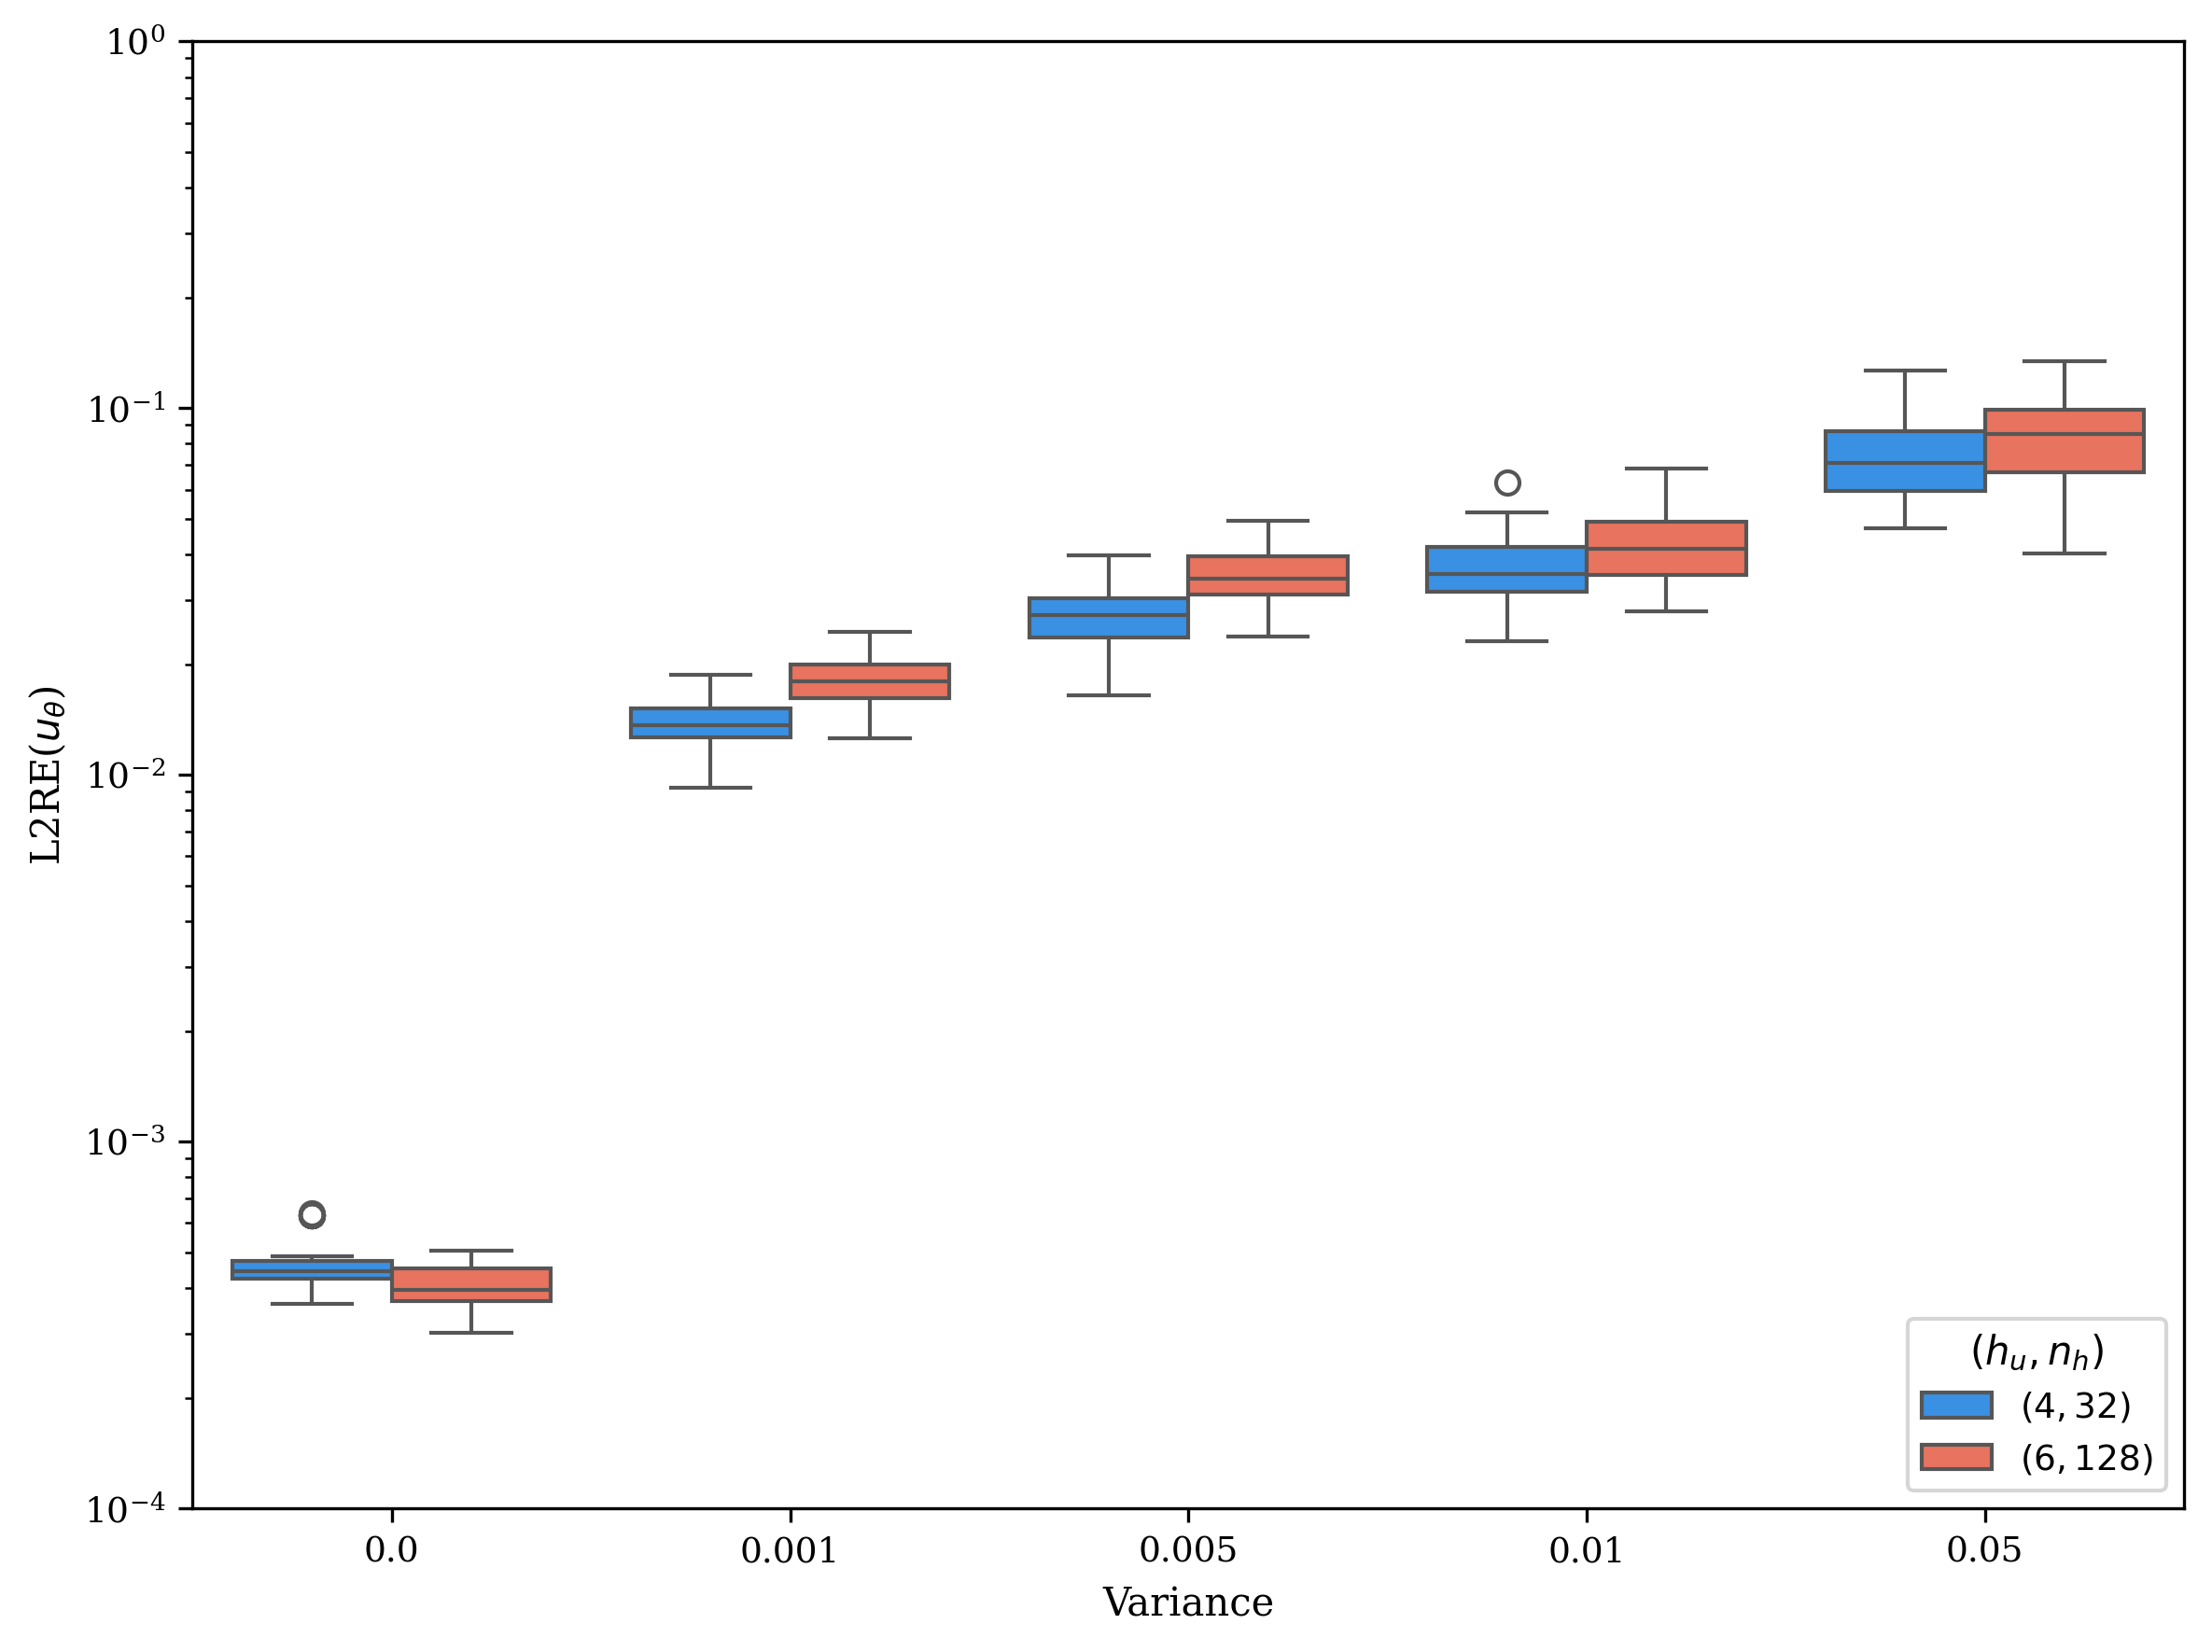

In [5]:
colors = sns.color_palette("Set2", len(u_structs))
colors = ['dodgerblue', 'tomato']
seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] 

# load errors
errorS_u = np.load(top_save_folder + 'errorS_uNN_updated.npy')

fig1, ax1 = plt.subplots(figsize=(8, 6))
data = []
for n in range(len(variances)):
    for s in range(len(subfolders)):
        for seed in seeds:
            for rep in range(NumRep):
                data.append([variances[n], errorS_u[s][n][seed-1][rep], u_structs[s]])
df = pd.DataFrame(data, columns=['Variance', r'L2RE($u_{\theta}$)', r'$(h_u, n_h)$'])
sns.boxplot(x='Variance', y=r'L2RE($u_{\theta}$)', hue=r'$(h_u, n_h)$', data=df, palette=colors, ax=ax1)
ax1.set_yscale('log')
ax1.set_ylim(1e-4, 1e0)
ax1.legend(loc ='lower right', title ='$(h_u, n_h)$')
fig1.tight_layout()
plt.show()

# save the figure as .svg file
fig1.savefig(top_save_folder + 'L2RE_uNN.svg', format='svg', bbox_inches='tight')

### Plot L2RE of u_reconstr wrt variances

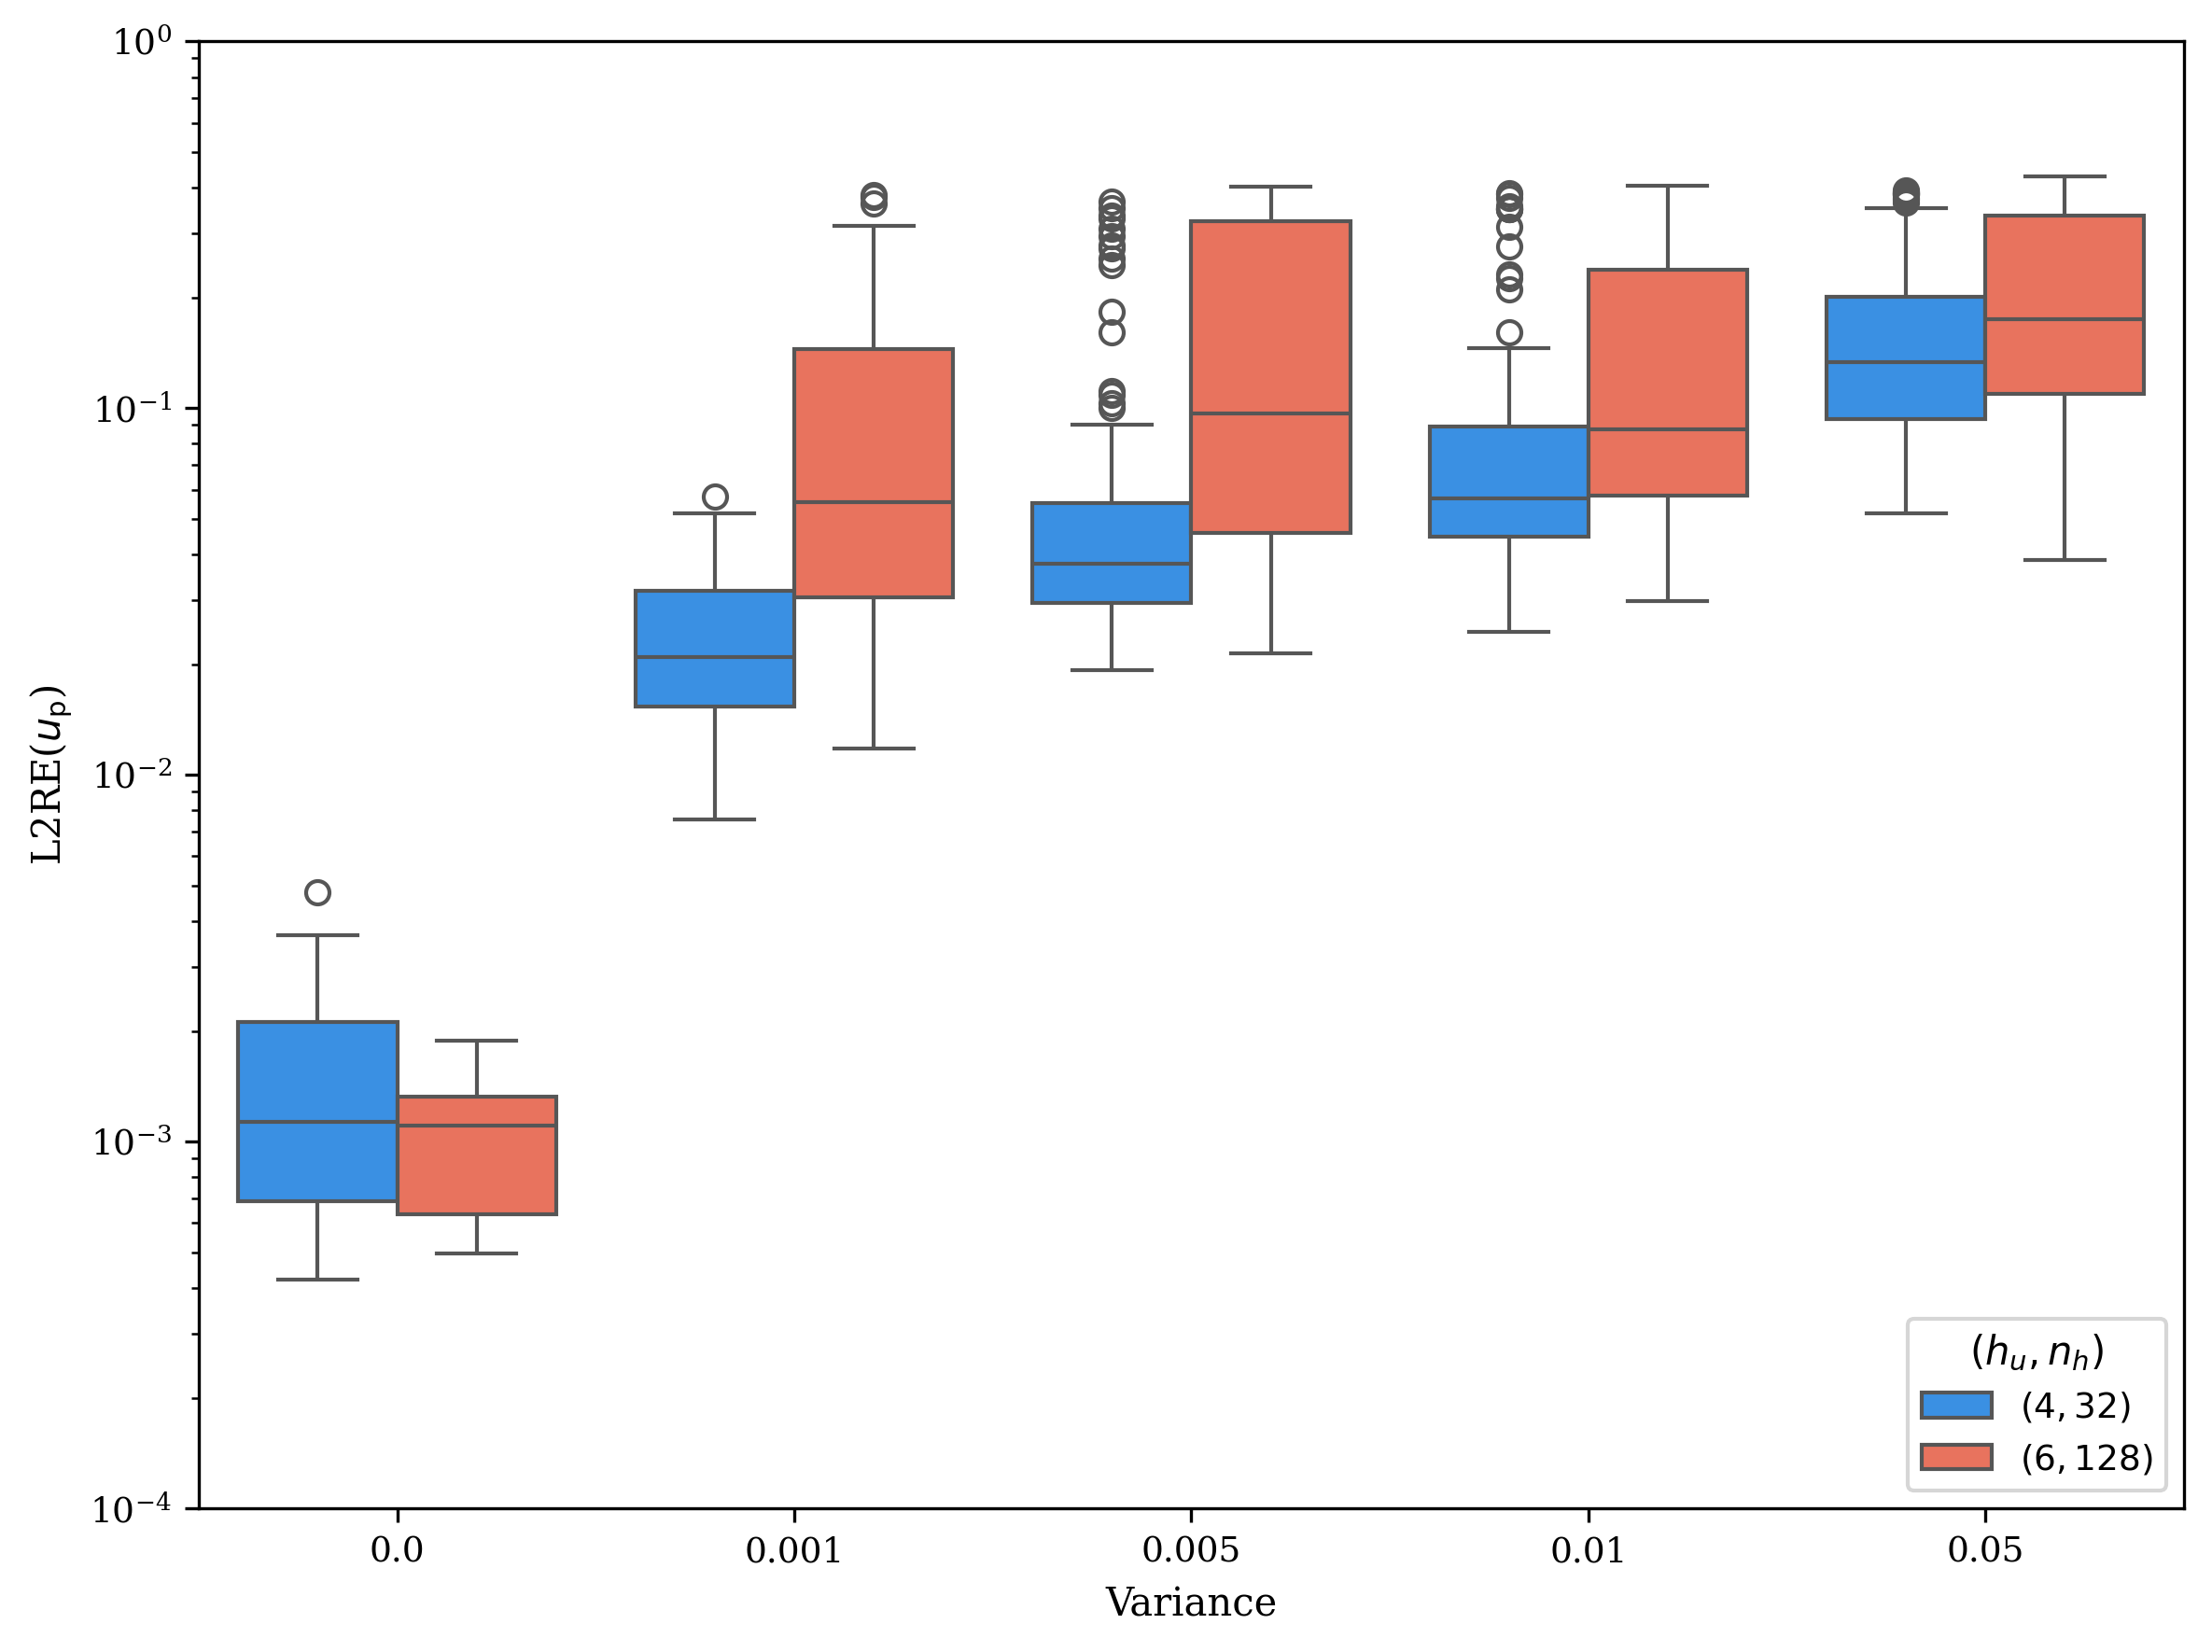

In [6]:
# colors = sns.color_palette("Set2", len(u_structs))

# load errors
errorS_u_reconstr = np.load(top_save_folder + 'errorS_u_reconstr_updated.npy')

fig2, ax2 = plt.subplots(figsize=(8, 6))
data1 = []
for n in range(len(variances)):
    for s in range(len(subfolders)):
        for seed in seeds:
            for rep in range(NumRep):
                data1.append([variances[n], errorS_u_reconstr[s][n][seed-1][rep], u_structs[s]])
df1 = pd.DataFrame(data1, columns=['Variance', r'L2RE($u_{\mathrm{p}}$)', r'$(h_u, n_h)$'])
sns.boxplot(x='Variance', y=r'L2RE($u_{\mathrm{p}}$)', hue=r'$(h_u, n_h)$', data=df1, palette=colors, ax=ax2)
ax2.set_yscale('log')
ax2.set_ylim(1e-4, 1e0)
ax2.legend(loc ='lower right', title ='$(h_u, n_h)$')
fig2.tight_layout()
plt.show()

# save the figure as .svg file
fig2.savefig(top_save_folder + 'L2RE_ureconstr.svg', format='svg', bbox_inches='tight')

### Plot: total validation loss over epochs

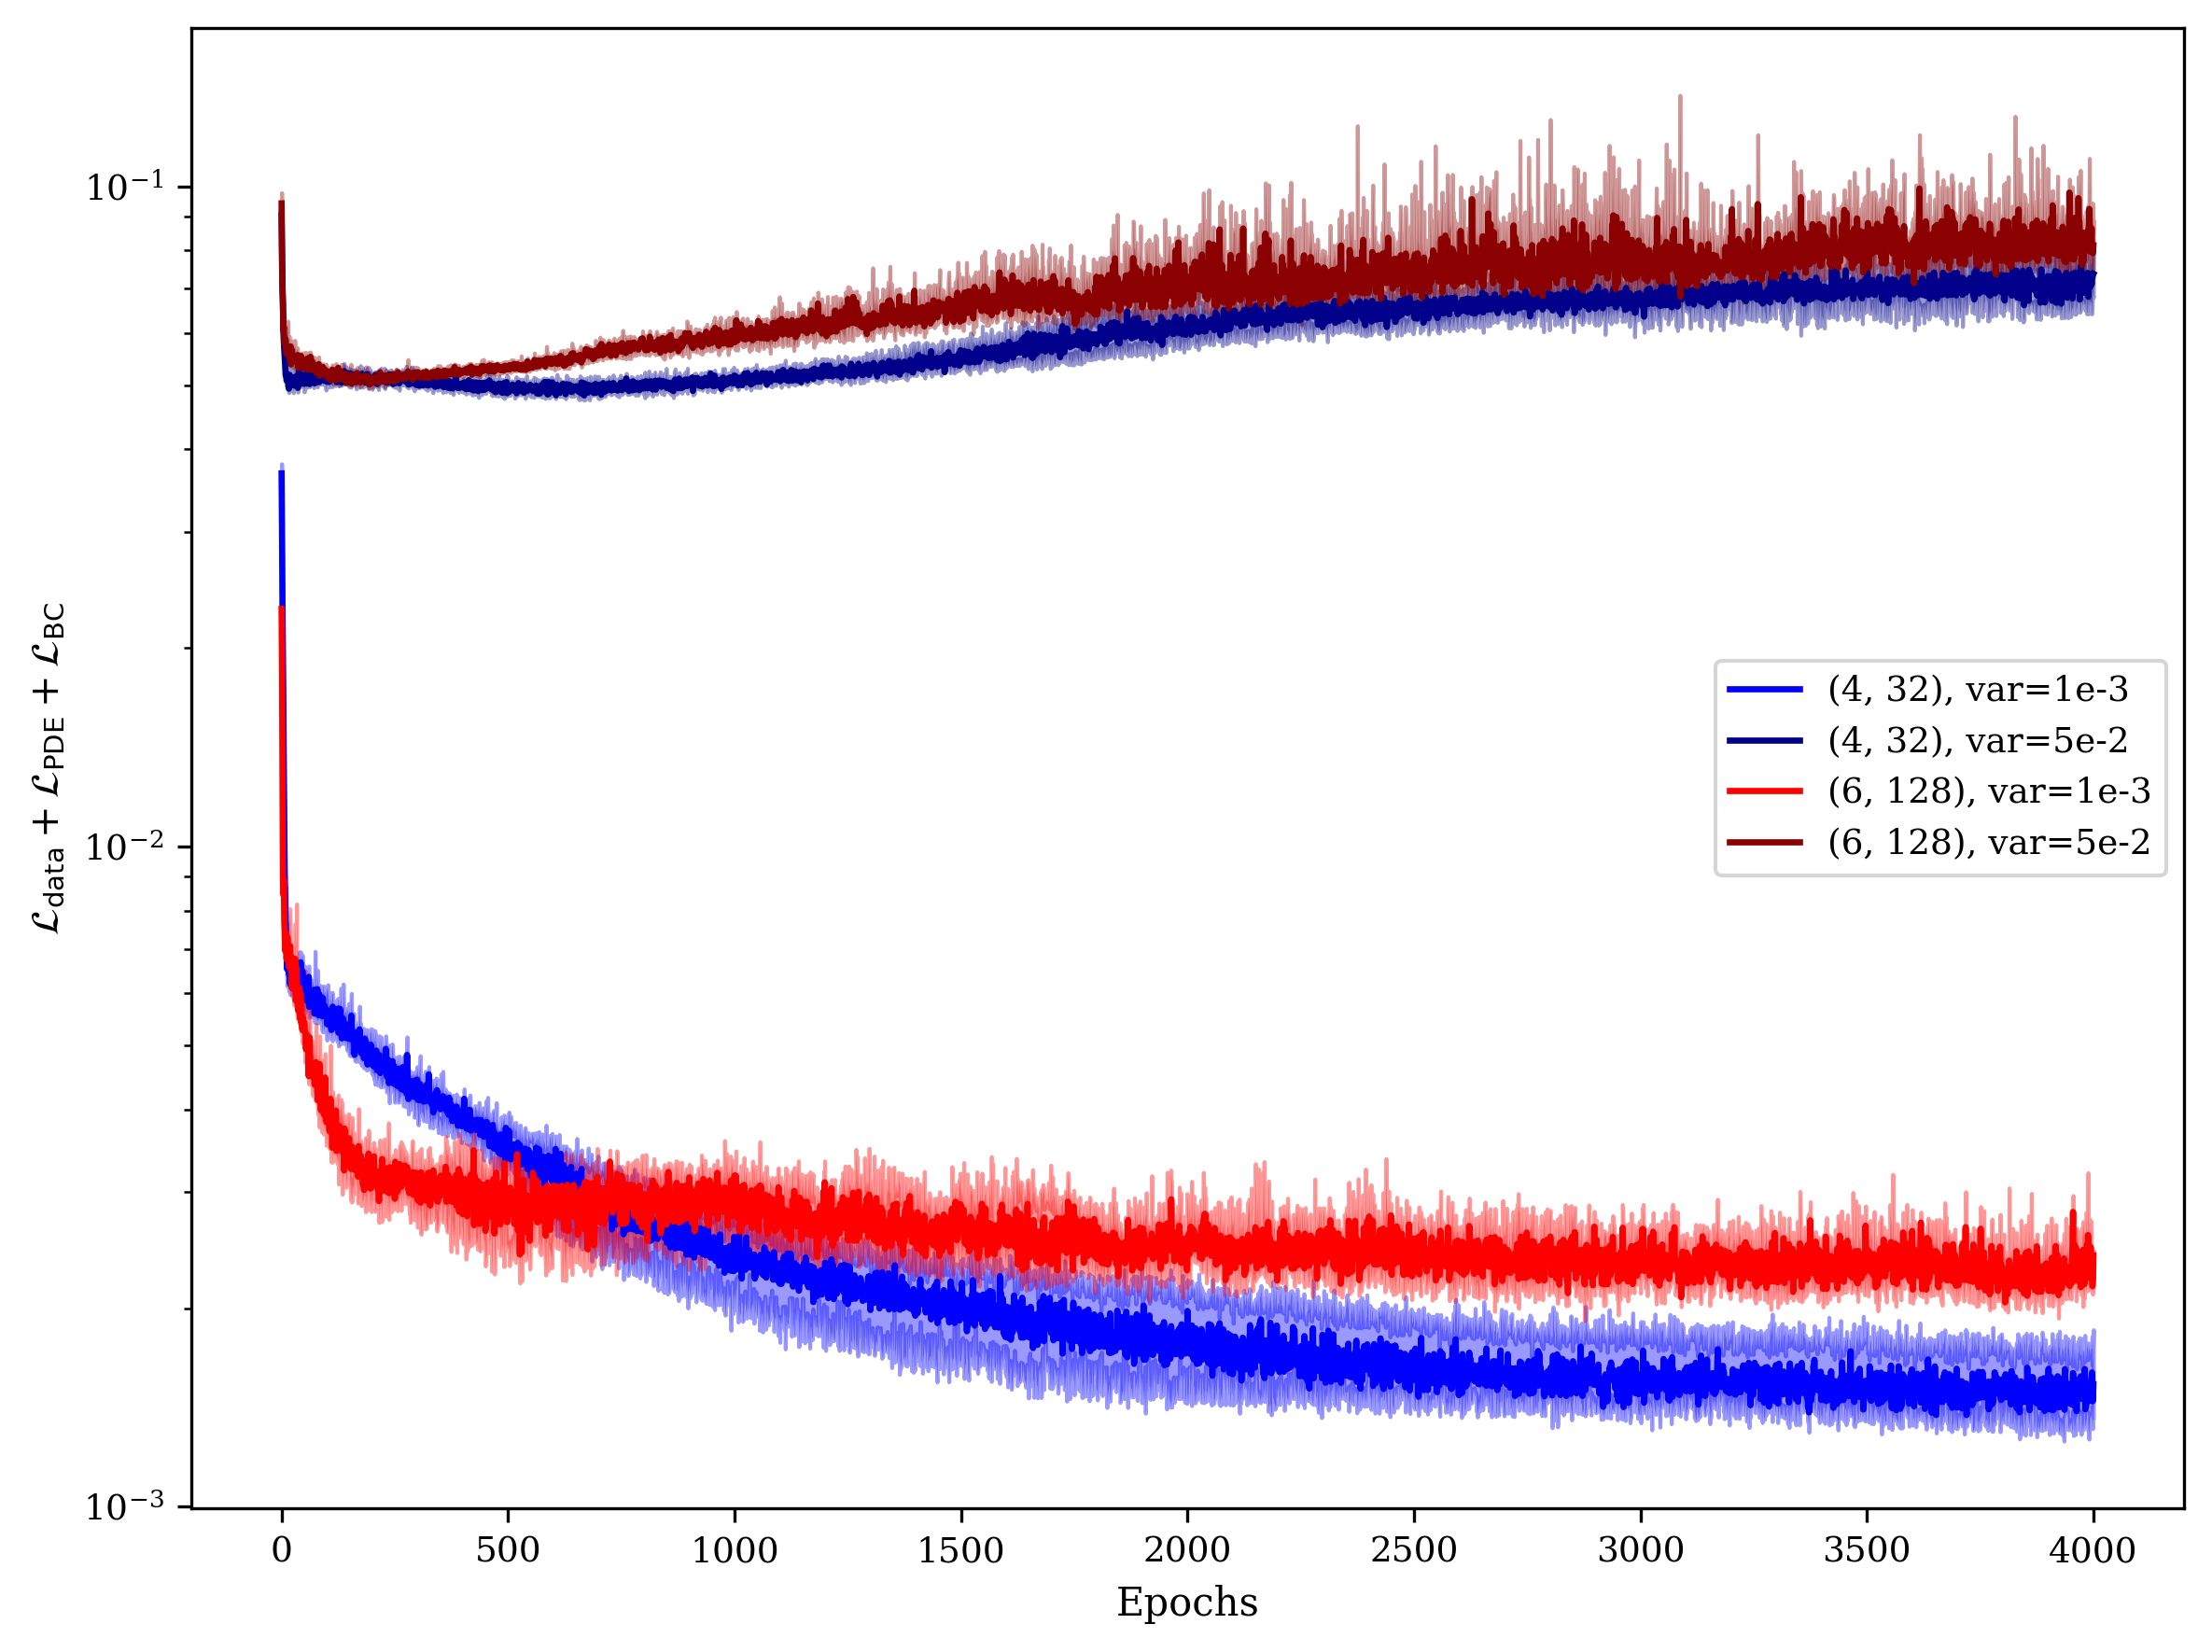

In [7]:
variances_ = [1e-3, 5e-2]
# blue for variance 1e-3 and (4, 32), orange for variance 1e-3 and (6, 128); 
# purple for variance 5e-2 and (4, 32), red for variance 5e-2 and (6, 128)
colors2 = [['blue', 'darkblue'], ['red', 'darkred']] 
linestyles = [['-', '-'], ['-', '-']]
legends = [['(4, 32), var=1e-3', '(4, 32), var=5e-2'], ['(6, 128), var=1e-3', '(6, 128), var=5e-2']]
fig3, ax3 = plt.subplots(figsize=(8, 6))

for s, subfolder in enumerate(subfolders):
    for n, var in enumerate(variances_):
        # load loss_info
        val_pdeloss_S = np.load(top_load_folder + subfolder + f'var{var}/val_pdeloss_S.npy', allow_pickle=True)
        val_uloss_S = np.load(top_load_folder + subfolder + f'var{var}/val_uloss_S.npy', allow_pickle=True)
        val_BCloss_S = np.load(top_load_folder + subfolder + f'var{var}/val_BCloss_S.npy', allow_pickle=True)
        val_pdeloss_S, val_uloss_S, val_BCloss_S = np.asarray(val_pdeloss_S, dtype=float), np.asarray(val_uloss_S, dtype=float), np.asarray(val_BCloss_S, dtype=float)

        total_loss = val_uloss_S + val_BCloss_S + val_pdeloss_S
        median_total_loss = np.median(total_loss, axis=0)
        q1_total_loss = np.percentile(total_loss, 25, axis=0)
        q3_total_loss = np.percentile(total_loss, 75, axis=0)

        ax3.plot(epoch_hist, median_total_loss, label=legends[s][n], color=colors2[s][n], linestyle=linestyles[s][n])
        ax3.fill_between(epoch_hist, q1_total_loss, q3_total_loss, color=colors2[s][n], alpha=0.4)

ax3.set_yscale('log')
ax3.set_xlabel('Epochs')
ax3.set_ylabel(r'$\mathcal{L}_{\mathrm{data}} + \mathcal{L}_{\mathrm{PDE}} + \mathcal{L}_{\mathrm{BC}}$')
ax3.legend(loc='best')
fig3.tight_layout()

plt.show()
fig3.savefig(top_save_folder + 'valloss_history.svg', format='svg', bbox_inches='tight')

### Plot: BINNs learning outcome for variance = 1e-3 and u_struc = (4, 32)

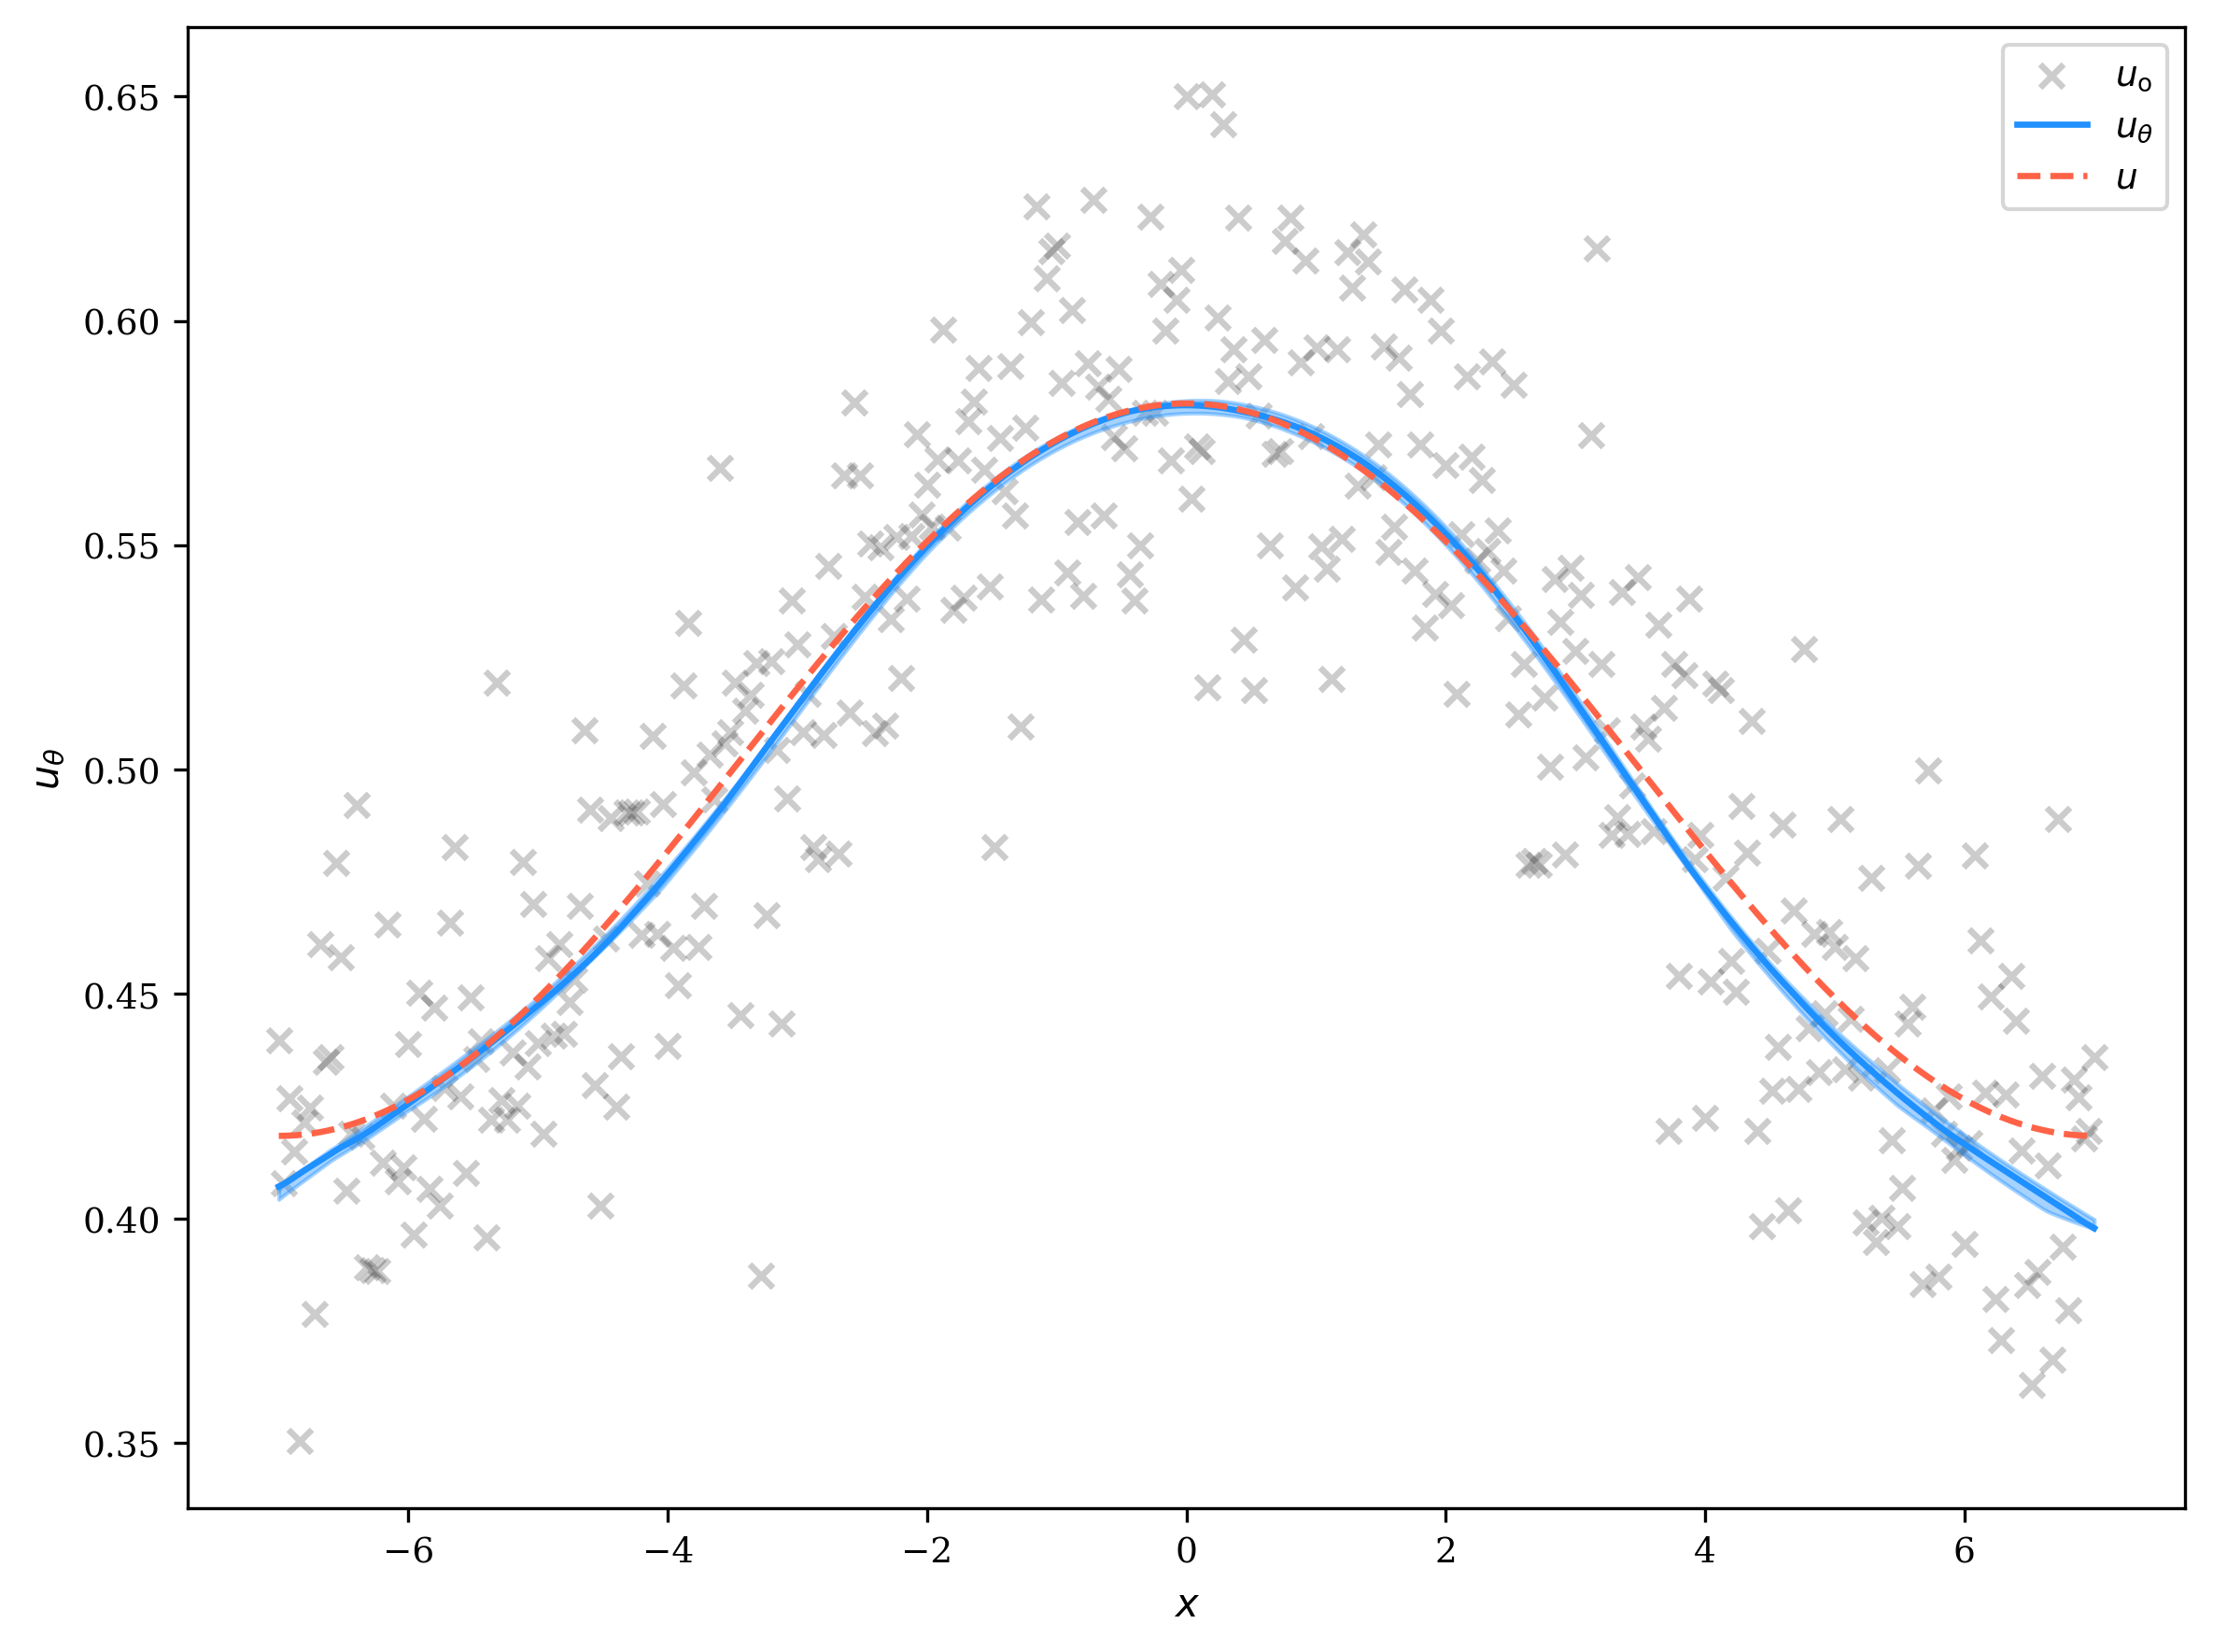

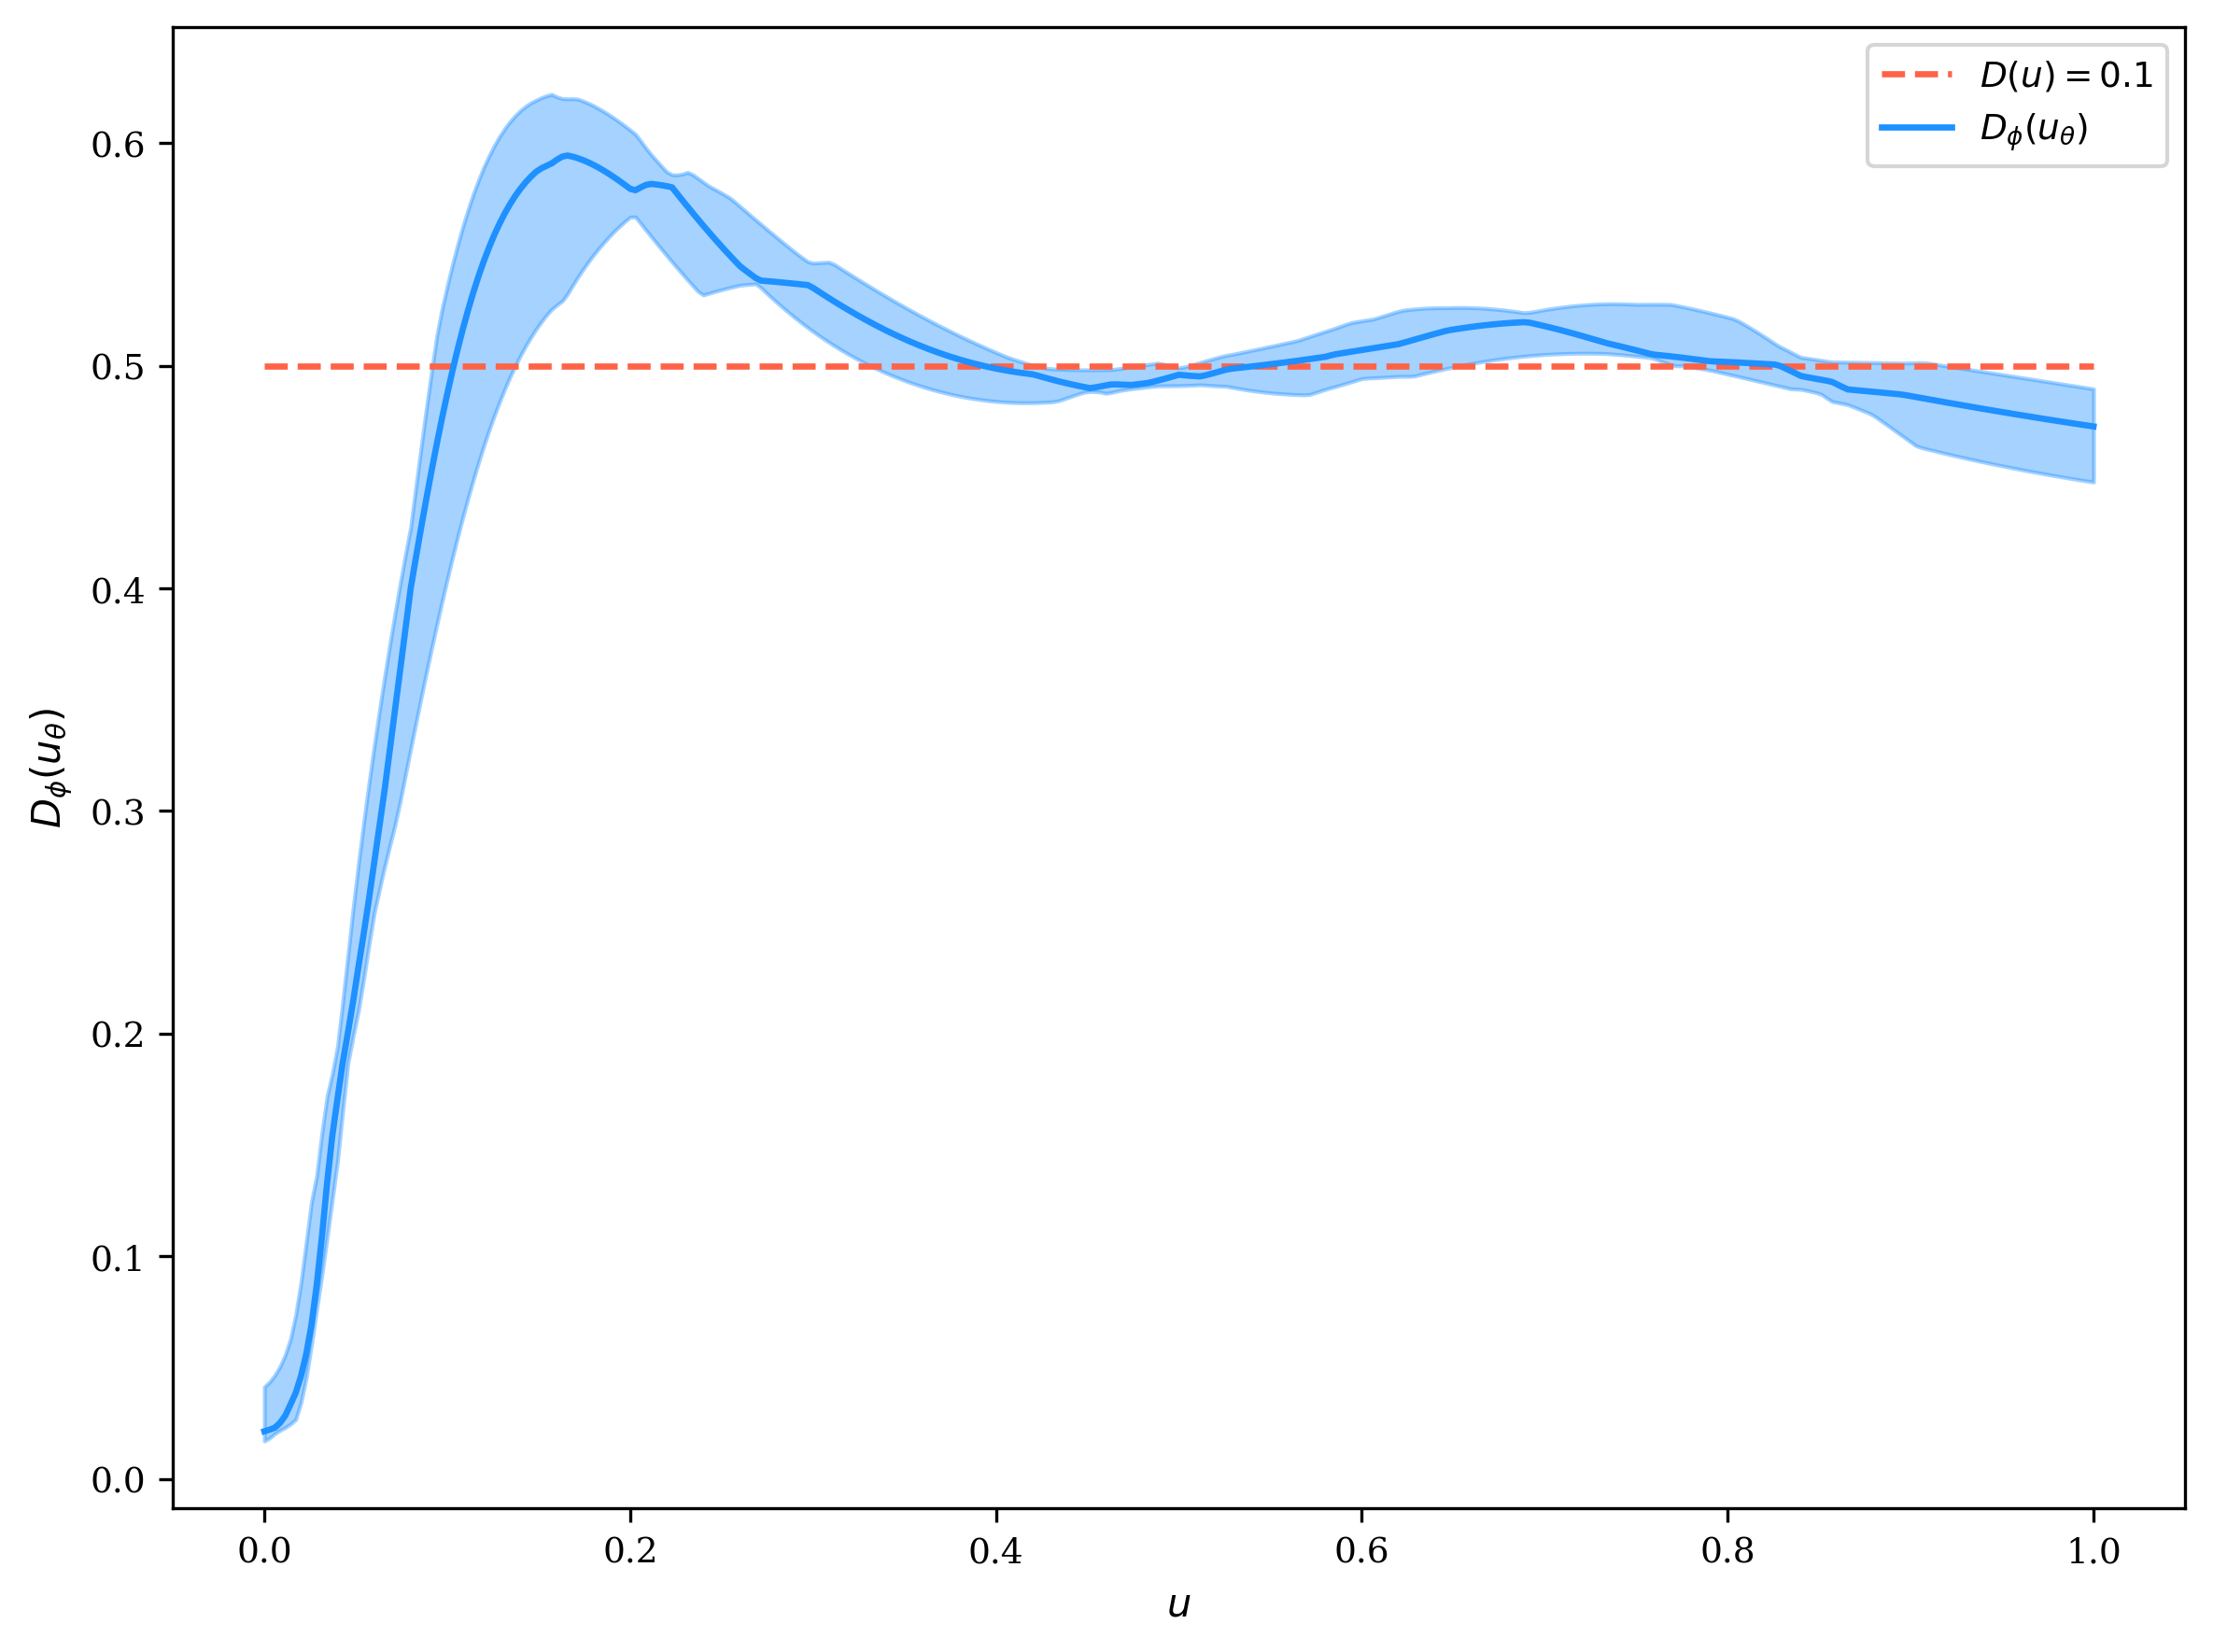

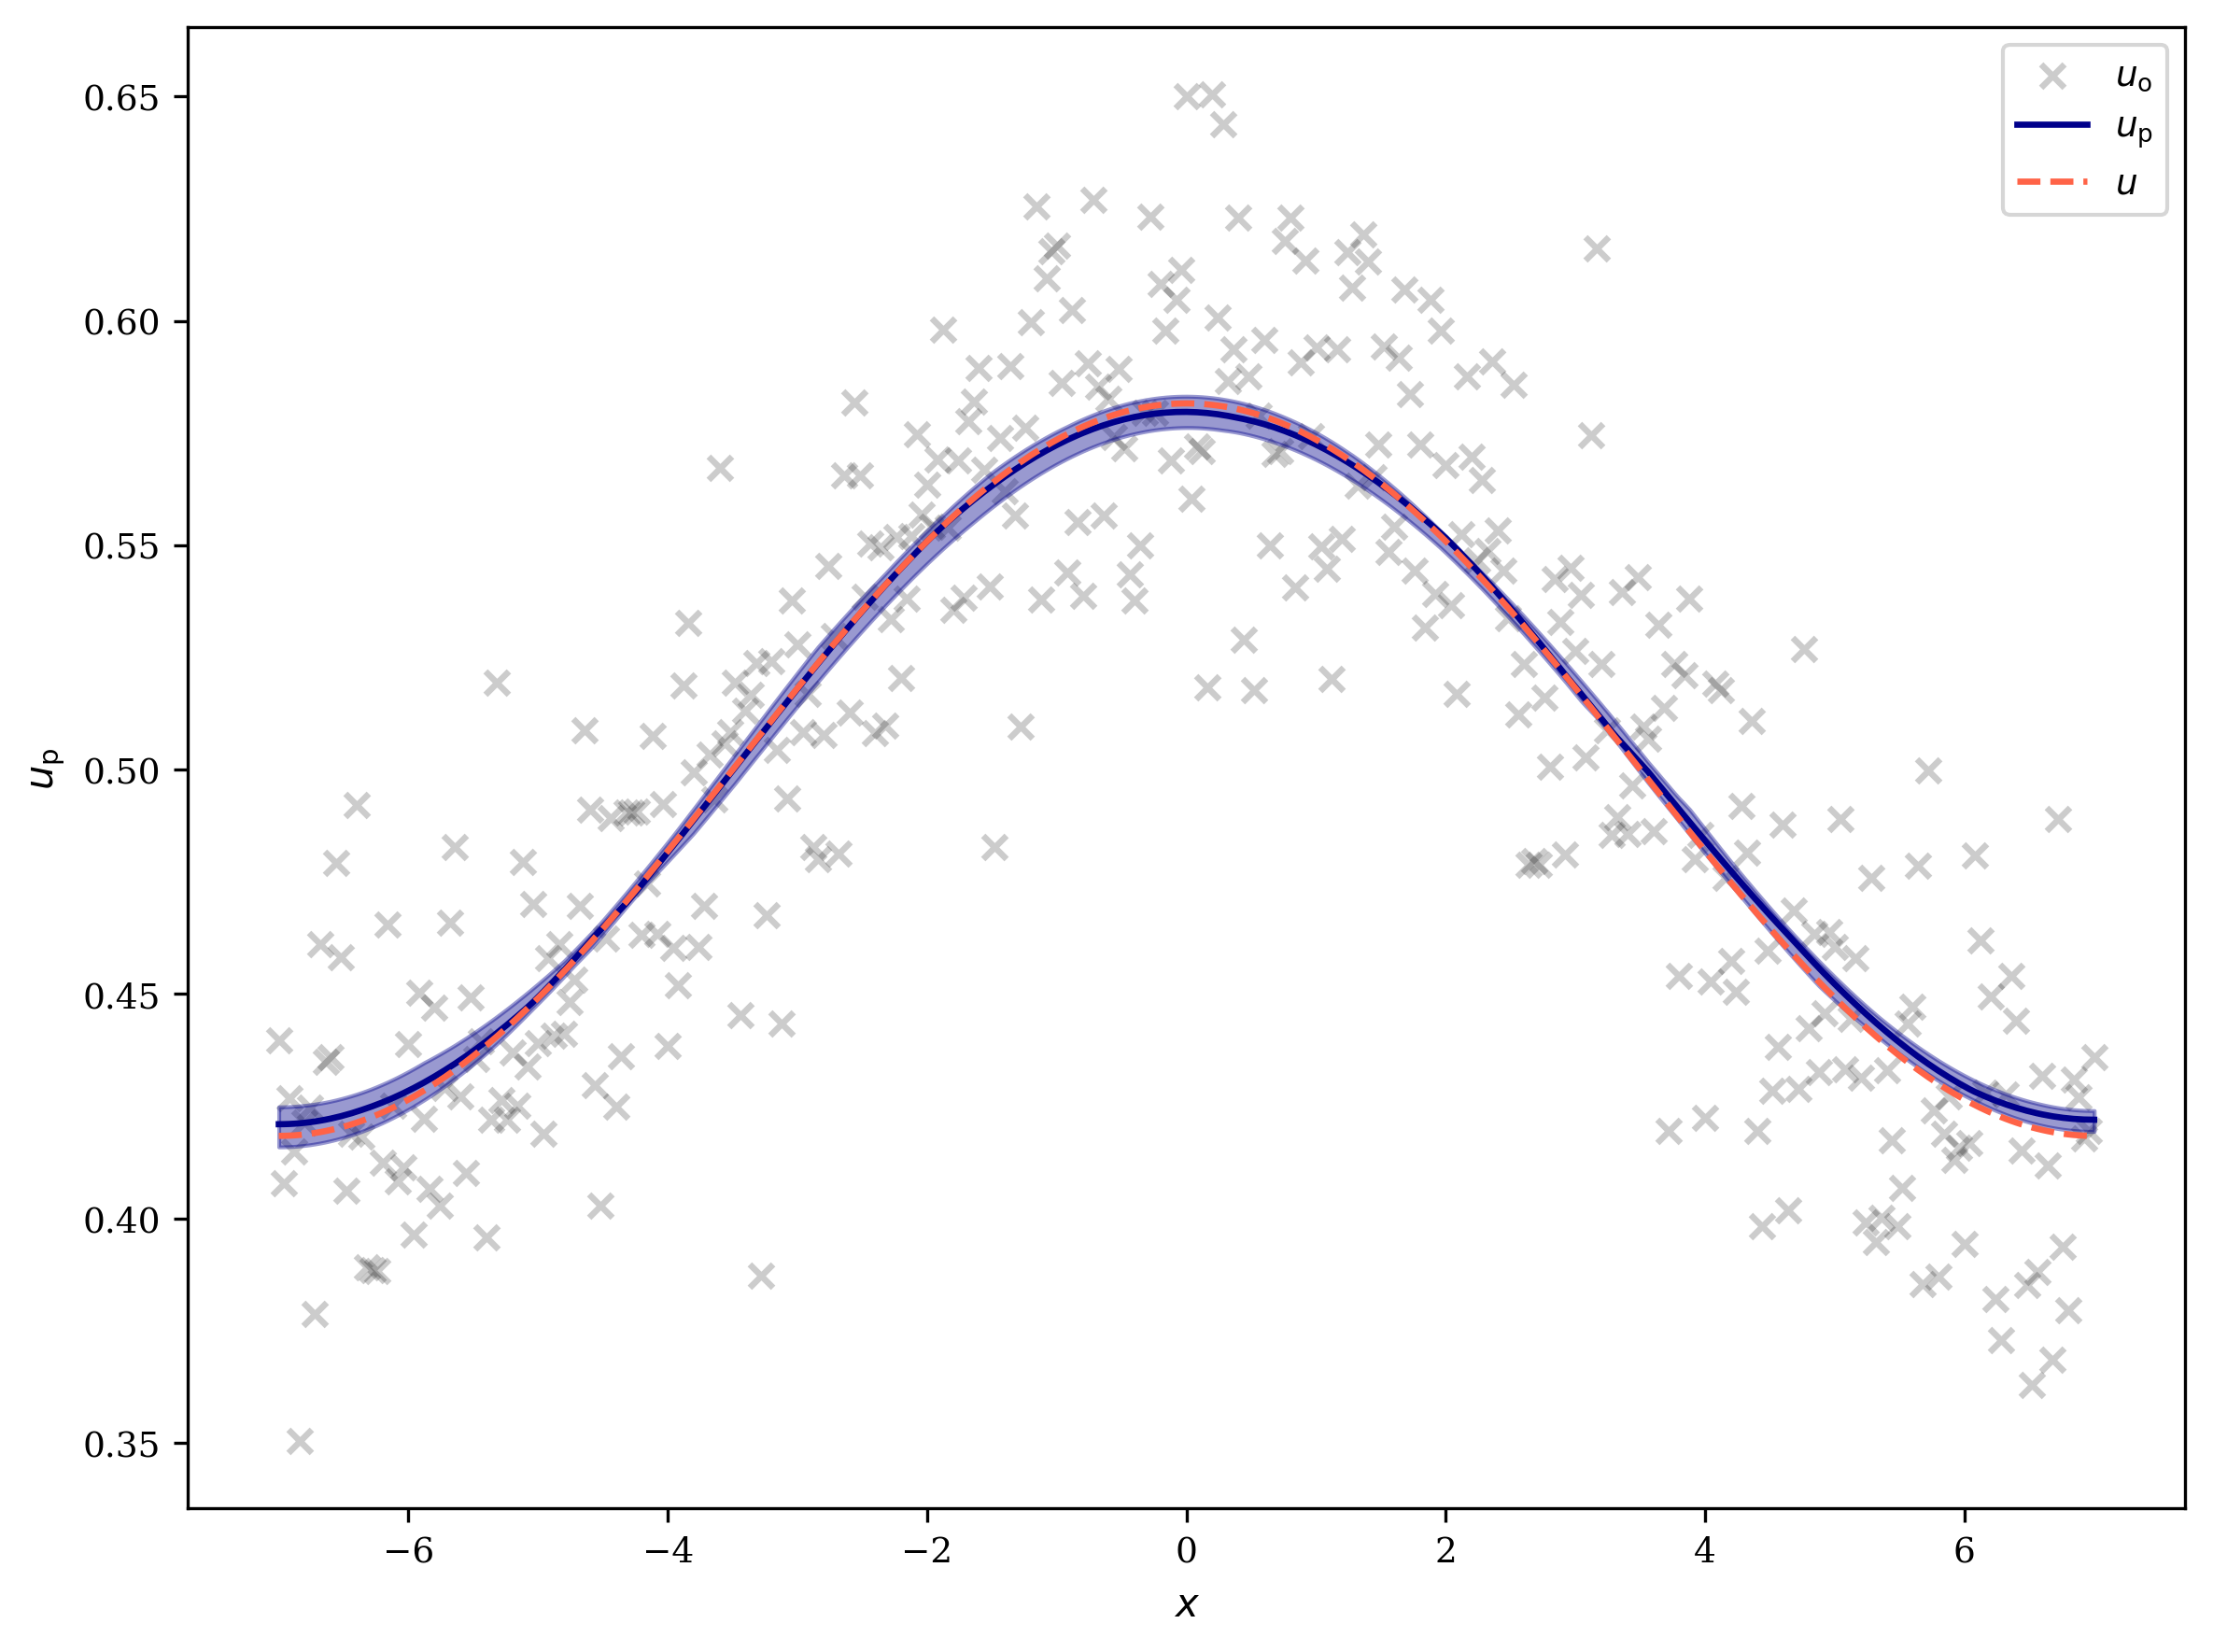

In [8]:
var = 1e-3

# load noisy training data: 
dataset = torch.load(top_load_folder + subfolders[0] + f'var{var}/full_dataset.pt', weights_only=False)  
x_data, u_data = dataset.tensors  # returns a tuple of tensors
x_data, u_data = x_data.numpy(), u_data.numpy()
x_data, t_data = x_data[:, 0], x_data[:, 1]
u_data = u_data.reshape(Nt, Nx)

u_learnt_all, D_learnt_all = [], []

for rep in range(NumRep):

    load_dir = top_load_folder + subfolders[0] + f'var{var}/Iter{rep}/'

    # load the leaernt u_NN
    u_learnt_np = np.load(load_dir + 'fullgrid_u_pred.npy')
    u_learnt_all.append(u_learnt_np)

    # load the learnt D_NN 
    test_D_pred_np = np.load(load_dir + 'fullgrid_D_pred.npy')
    D_learnt_all.append(test_D_pred_np)

u_learnt_all = np.array(u_learnt_all) # shape (NumRep, Nt, Nx)
u_learnt_median = np.median(u_learnt_all, axis=0)
u_learnt_25perc = np.percentile(u_learnt_all, 25, axis=0)
u_learnt_75perc = np.percentile(u_learnt_all, 75, axis=0)
D_learnt_all = np.array(D_learnt_all) # shape (NumRep, Nt, Nx)
D_learnt_median = np.median(D_learnt_all, axis=0)
D_learnt_25perc = np.percentile(D_learnt_all, 25, axis=0)
D_learnt_75perc = np.percentile(D_learnt_all, 75, axis=0)

# plot for u_NN
fig4, ax4 = plt.subplots(figsize=(8, 6))
t0, tfinal = 0, -1

# plot the learnt solution at t0 and tfinal with median and 25-75 percentile shaded area
# ax4.plot(x_train, u_learnt_median[t0, :], color='dodgerblue', label=r'$u_{\theta}(x, t)$' if t0==0 else None)
# ax4.fill_between(x_train, u_learnt_25perc[t0, :], u_learnt_75perc[t0, :], color='dodgerblue', alpha=0.4)
ax4.scatter(x_train, u_data[tfinal, :], color='black', alpha=0.2, marker='x', label = r'$u_\mathrm{o}$')
ax4.plot(x_train, u_learnt_median[tfinal, :], color='dodgerblue', label = r'$u_\theta$')
ax4.fill_between(x_train, u_learnt_25perc[tfinal, :], u_learnt_75perc[tfinal, :], color='dodgerblue', alpha=0.4)
# plot the noiseless and the noisy training data at t0 and tfinal
# ax4.plot(x_train, u_true[t0, :], '--', color='tomato', label=r'$u(x, t=0, 2)$' if t0==0 else None)
# ax4.scatter(x_train, u_data[t0, :], color='tomato', alpha=0.2, label=r'$\bar{u}(x, t=0, 2)$' if t0 == 0 else "")
ax4.plot(x_train, u_true[tfinal, :], '--', color='tomato', label = r'$u$')

# ax4.set_title(rf'Learnt $u_{{\theta}}$ with variance ${var}$, $(h_u, n_u)=(4, 32)$')
ax4.set_xlabel(r'$x$')
ax4.set_ylabel(r'$u_{\theta}$')
ax4.legend()
# ax4.set_ylim([-1.0, 2.0])

fig4.tight_layout()
plt.show()
fig4.savefig(top_save_folder + f'uNN_var{var}.svg', format='svg', bbox_inches='tight')

# plot for D_NN
fig5, ax5 = plt.subplots(figsize=(8, 6))
ax5.plot(U_grid, D_true * np.ones_like(U_grid), '--', color='tomato', label=r'$D(u)=0.1$')
ax5.plot(U_grid, D_learnt_median.flatten(), color='dodgerblue', label=r'$D_{\phi}(u_{\theta})$')
ax5.fill_between(U_grid, D_learnt_25perc.flatten(), D_learnt_75perc.flatten(), color='dodgerblue', alpha=0.4)
ax5.set_xlabel(r'$u$')
ax5.set_ylabel(r'$D_{\phi}(u_{\theta})$')
ax5.legend()
# ax5.set_ylim([0.0, 1.0])
fig5.tight_layout()
plt.show()
fig5.savefig(top_save_folder + f'DNN_var{var}.svg', format='svg', bbox_inches='tight')

# plot for the reconstructed solution u_reconstr 
u_pred_all = np.load(top_save_folder + 'u_pred_all.npy')
u_pred_ = u_pred_all[0][1]
u_pred_median = np.median(u_pred_, axis=0)
u_pred_25perc = np.percentile(u_pred_, 25, axis=0)
u_pred_75perc = np.percentile(u_pred_, 75, axis=0)

fig6, ax6 = plt.subplots(figsize=(8, 6))
ax6.set_xlabel(r'$x$')
ax6.set_ylabel(r'$u_{\mathrm{p}}$')

# ax6.plot(x_train, u_true[t0, :], 'r--', label=r'$u(x, t=0, 2)$')
# ax6.plot(x_train, u_pred_median[t0, :], color='dodgerblue', label=r'$u_{\mathrm{p}}(x, t=0, 2)$')
# ax6.fill_between(x_train, u_pred_25perc[t0, :], u_pred_75perc[t0, :], color='dodgerblue', alpha=0.4)
# ax6.plot(x_train, u_true[t0, :], '--', color='tomato')
# ax6.scatter(x_train, u_data[t0, :], color='tomato', alpha=0.2, label=r'$\bar{u}(x, t=0, 2)$')

ax6.scatter(x_train, u_data[tfinal, :], color='black', marker='x', alpha=0.2, label = r'$u_\mathrm{o}$')
ax6.plot(x_train, u_pred_median[tfinal, :], color='darkblue', label=r'$u_\mathrm{p}$')
ax6.fill_between(x_train, u_pred_25perc[tfinal, :], u_pred_75perc[tfinal, :], color = 'darkblue', alpha=0.4)
ax6.plot(x_train, u_true[tfinal, :], '--', color='tomato', label=r'$u$')



# ax6.set_ylim([0, 1.0]) 
ax6.legend()
fig6.tight_layout()
plt.show()
fig6.savefig(top_save_folder + f'u_reconstr_var{var}.svg', format='svg', bbox_inches='tight')




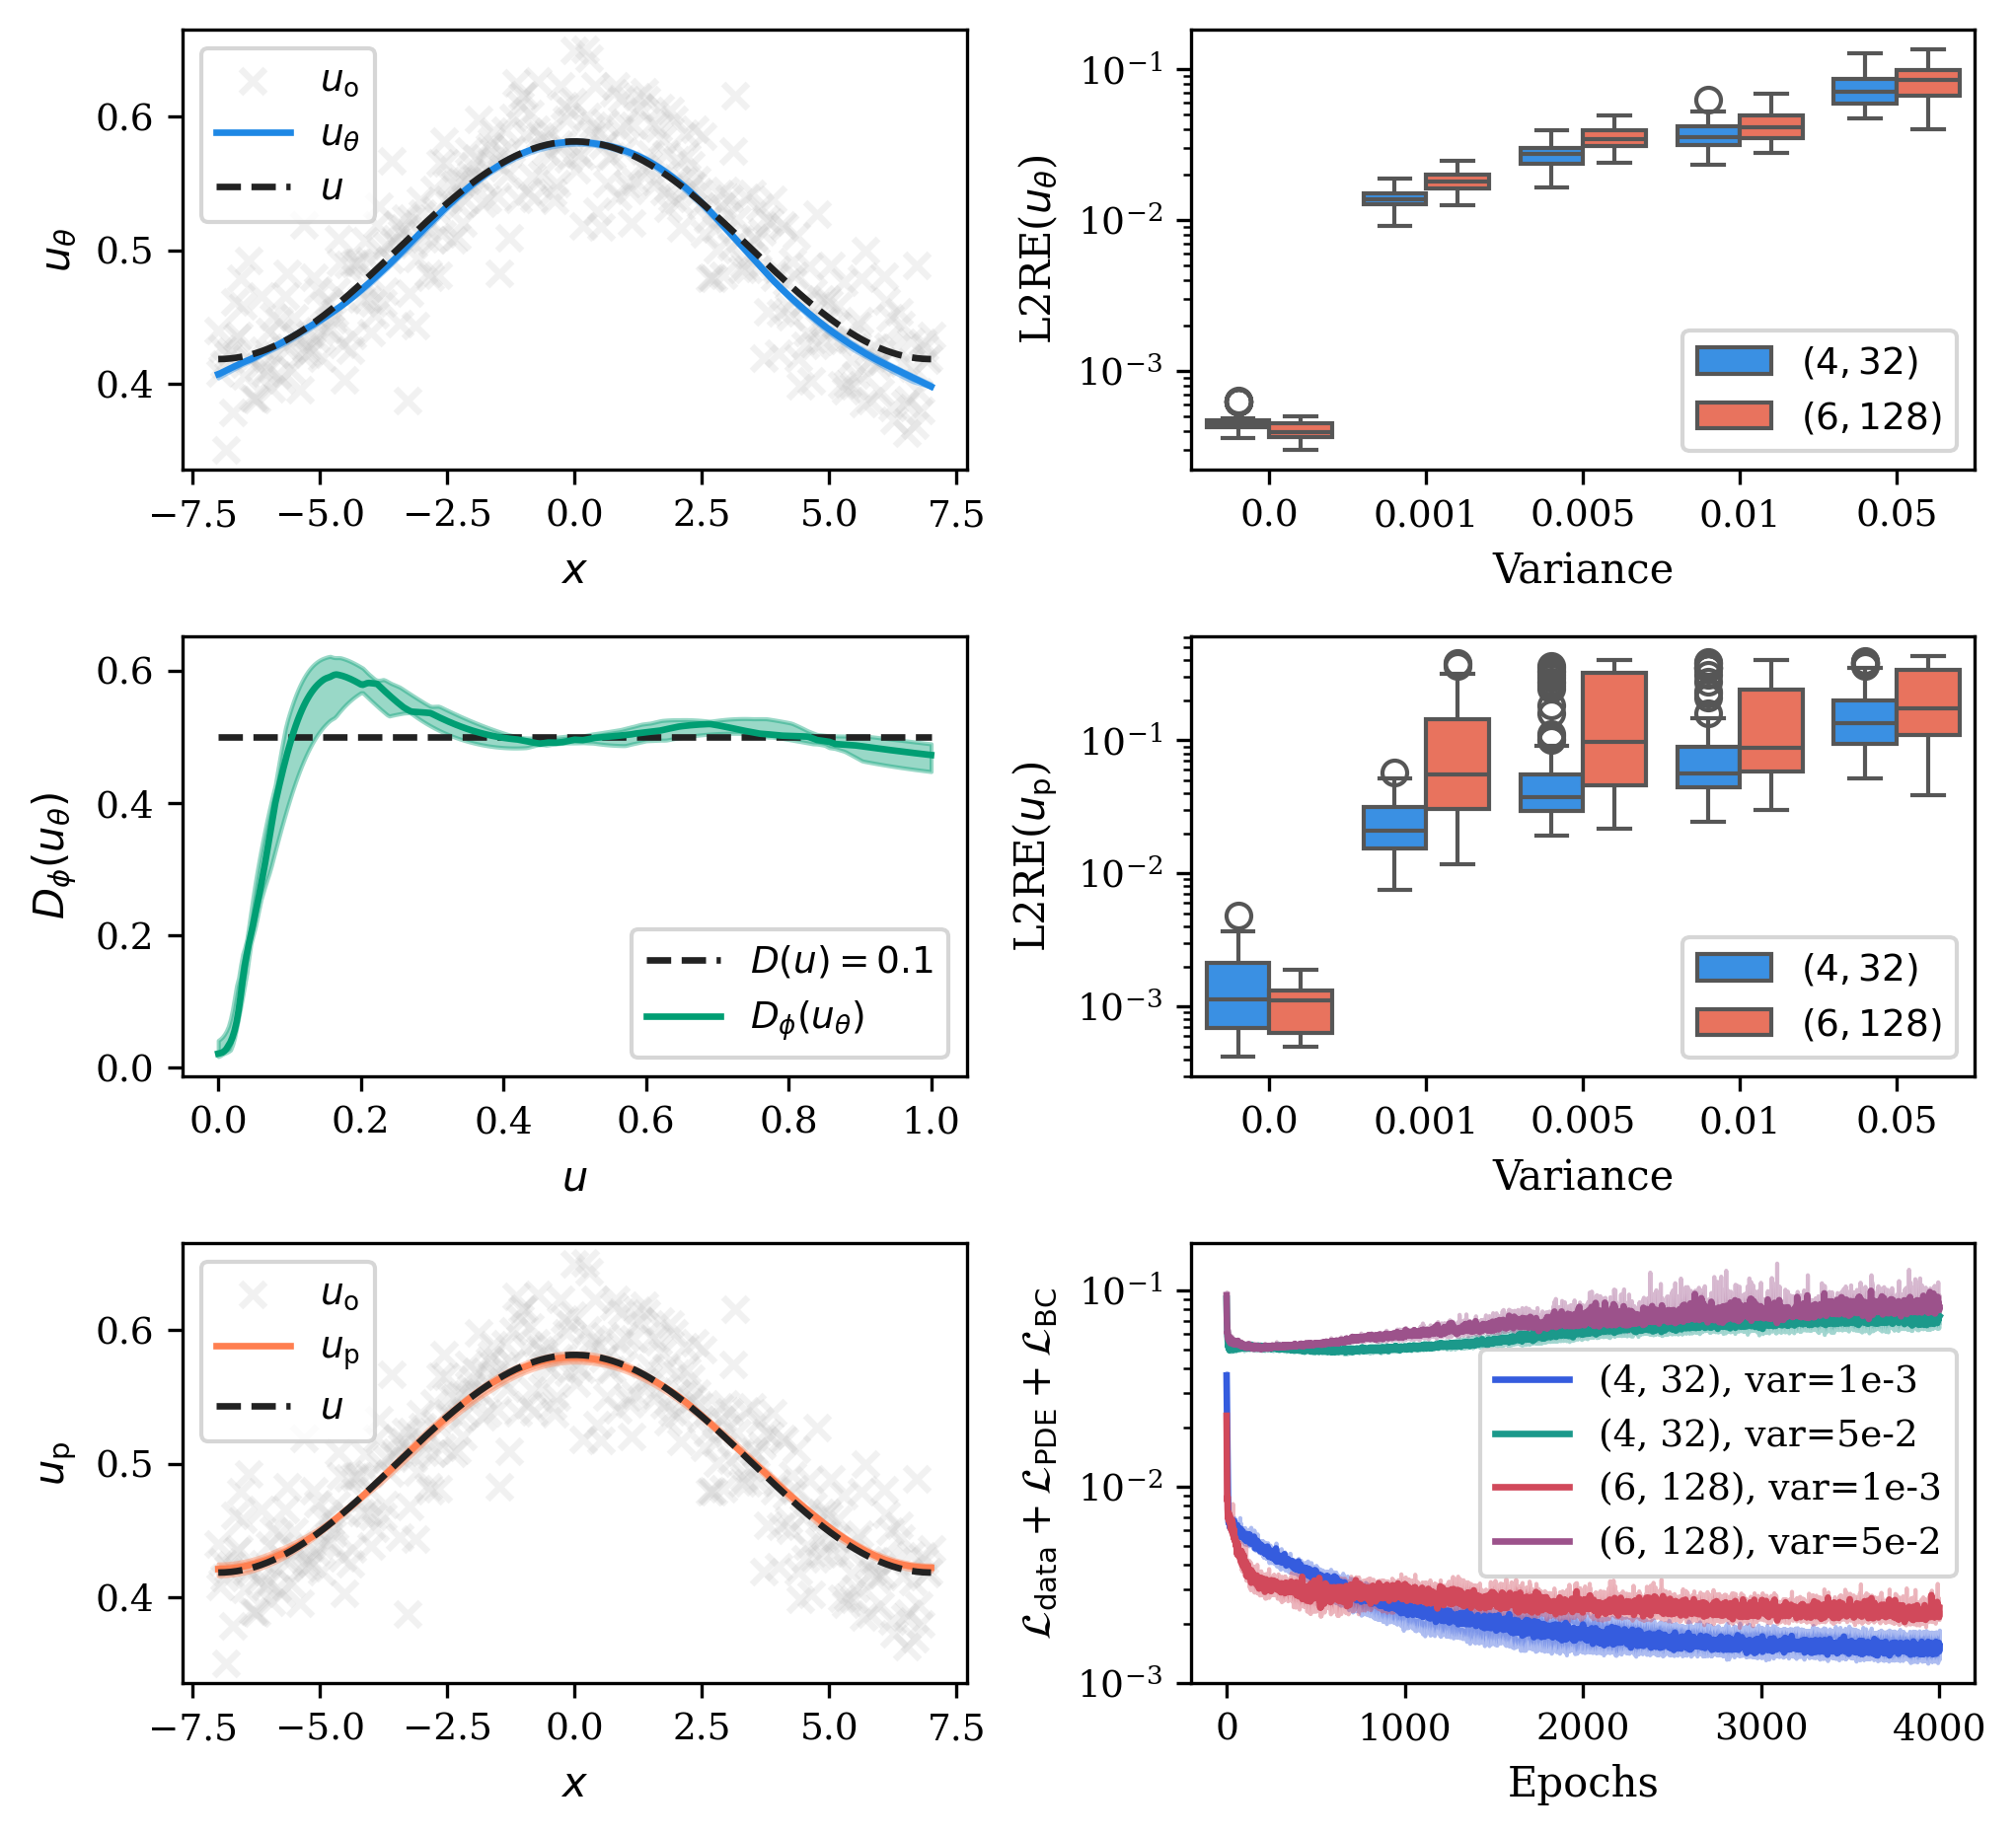

In [9]:
fig, ax = plt.subplots(3, 2, figsize=(WIDTH, 1.5*HEIGHT))

OBS = "#BDBDBD"       # observed data / u_o

OBS_EDGE = "#9E9E9E"

U_THETA = "#1E88E5"   # dodgerblue-ish

U_P = "#FF7F50"       # tomato-ish

TRUE = "#222222"  

D_COLOR = "#009E73"   # teal-green

colors = ['dodgerblue', 'tomato']

ax[0,0].scatter(x_train, u_data[tfinal, :], color=OBS, alpha=0.2, marker='x', label = r'$u_\mathrm{o}$')
ax[0,0].plot(x_train, u_learnt_median[tfinal, :], color=U_THETA, label = r'$u_\theta$')
ax[0,0].fill_between(x_train, u_learnt_25perc[tfinal, :], u_learnt_75perc[tfinal, :], color=U_THETA, alpha=0.4)
ax[0,0].plot(x_train, u_true[tfinal, :], '--', color=TRUE, label = r'$u$')
ax[0,0].set_xlabel(r'$x$')
ax[0,0].set_ylabel(r'$u_{\theta}$')
ax[0,0].legend()

sns.boxplot(x='Variance', y=r'L2RE($u_{\theta}$)', hue=r'$(h_u, n_h)$', data=df, palette=colors, ax=ax[0,1])
ax[0,1].set_yscale('log')
# ax[0,1].set_ylim(1e-4, 1e0)
ax[0,1].legend(loc='lower right')

ax[1,0].plot(U_grid, D_true * np.ones_like(U_grid), '--', color=TRUE, label=r'$D(u)=0.1$')
ax[1,0].plot(U_grid, D_learnt_median.flatten(), color=D_COLOR, label=r'$D_{\phi}(u_{\theta})$')
ax[1,0].fill_between(U_grid, D_learnt_25perc.flatten(), D_learnt_75perc.flatten(), color=D_COLOR, alpha=0.4)
ax[1,0].set_xlabel(r'$u$')
ax[1,0].set_ylabel(r'$D_{\phi}(u_{\theta})$')
ax[1,0].legend()

sns.boxplot(x='Variance', y=r'L2RE($u_{\mathrm{p}}$)', hue=r'$(h_u, n_h)$', data=df1, palette=colors, ax=ax[1,1])
ax[1,1].set_yscale('log')
# ax[1,1].set_ylim(1e-4, 1e0)
ax[1,1].legend(loc='lower right')

ax[2,0].scatter(x_train, u_data[tfinal, :], color=OBS, marker='x', alpha=0.2, label = r'$u_\mathrm{o}$')
ax[2,0].plot(x_train, u_pred_median[tfinal, :], color=U_P, label=r'$u_\mathrm{p}$')
ax[2,0].fill_between(x_train, u_pred_25perc[tfinal, :], u_pred_75perc[tfinal, :], color = U_P, alpha=0.4)
ax[2,0].plot(x_train, u_true[tfinal, :], '--', color=TRUE, label=r'$u$')
ax[2,0].set_xlabel(r'$x$')
ax[2,0].set_ylabel(r'$u_{\mathrm{p}}$')
ax[2,0].legend()

LOSS_COLORS = {

    ("(4,32)", "1e-3"): "#355CDE",   # deeper royal blue

    ("(4,32)", "5e-2"): "#1B998B",   # teal-green

    ("(6,128)", "1e-3"): "#D1495B",  # deep rose-red

    ("(6,128)", "5e-2"): "#9C528B",  # muted purple

}

colors2 =[["#355CDE", "#1B998B"], ["#D1495B", "#9C528B"]]

for s, subfolder in enumerate(subfolders):
    for n, var in enumerate(variances_):
        # load loss_info
        val_pdeloss_S = np.load(top_load_folder + subfolder + f'var{var}/val_pdeloss_S.npy', allow_pickle=True)
        val_uloss_S = np.load(top_load_folder + subfolder + f'var{var}/val_uloss_S.npy', allow_pickle=True)
        val_BCloss_S = np.load(top_load_folder + subfolder + f'var{var}/val_BCloss_S.npy', allow_pickle=True)
        val_pdeloss_S, val_uloss_S, val_BCloss_S = np.asarray(val_pdeloss_S, dtype=float), np.asarray(val_uloss_S, dtype=float), np.asarray(val_BCloss_S, dtype=float)

        total_loss = val_uloss_S + val_BCloss_S + val_pdeloss_S
        median_total_loss = np.median(total_loss, axis=0)
        q1_total_loss = np.percentile(total_loss, 25, axis=0)
        q3_total_loss = np.percentile(total_loss, 75, axis=0)

        ax[2,1].plot(epoch_hist, median_total_loss, label=legends[s][n], color=colors2[s][n], linestyle=linestyles[s][n])
        ax[2,1].fill_between(epoch_hist, q1_total_loss, q3_total_loss, color=colors2[s][n], alpha=0.4)

ax[2,1].set_yscale('log')
ax[2,1].set_xlabel('Epochs')
ax[2,1].set_ylabel(r'$\mathcal{L}_{\mathrm{data}} + \mathcal{L}_{\mathrm{PDE}} + \mathcal{L}_{\mathrm{BC}}$')
ax[2,1].legend(loc='best')

plt.tight_layout()
fig.savefig(top_save_folder + f'fig2.svg', format='svg', bbox_inches='tight')
fig.savefig(top_save_folder + f'fig2.pdf', format='pdf', bbox_inches='tight')
plt.show()


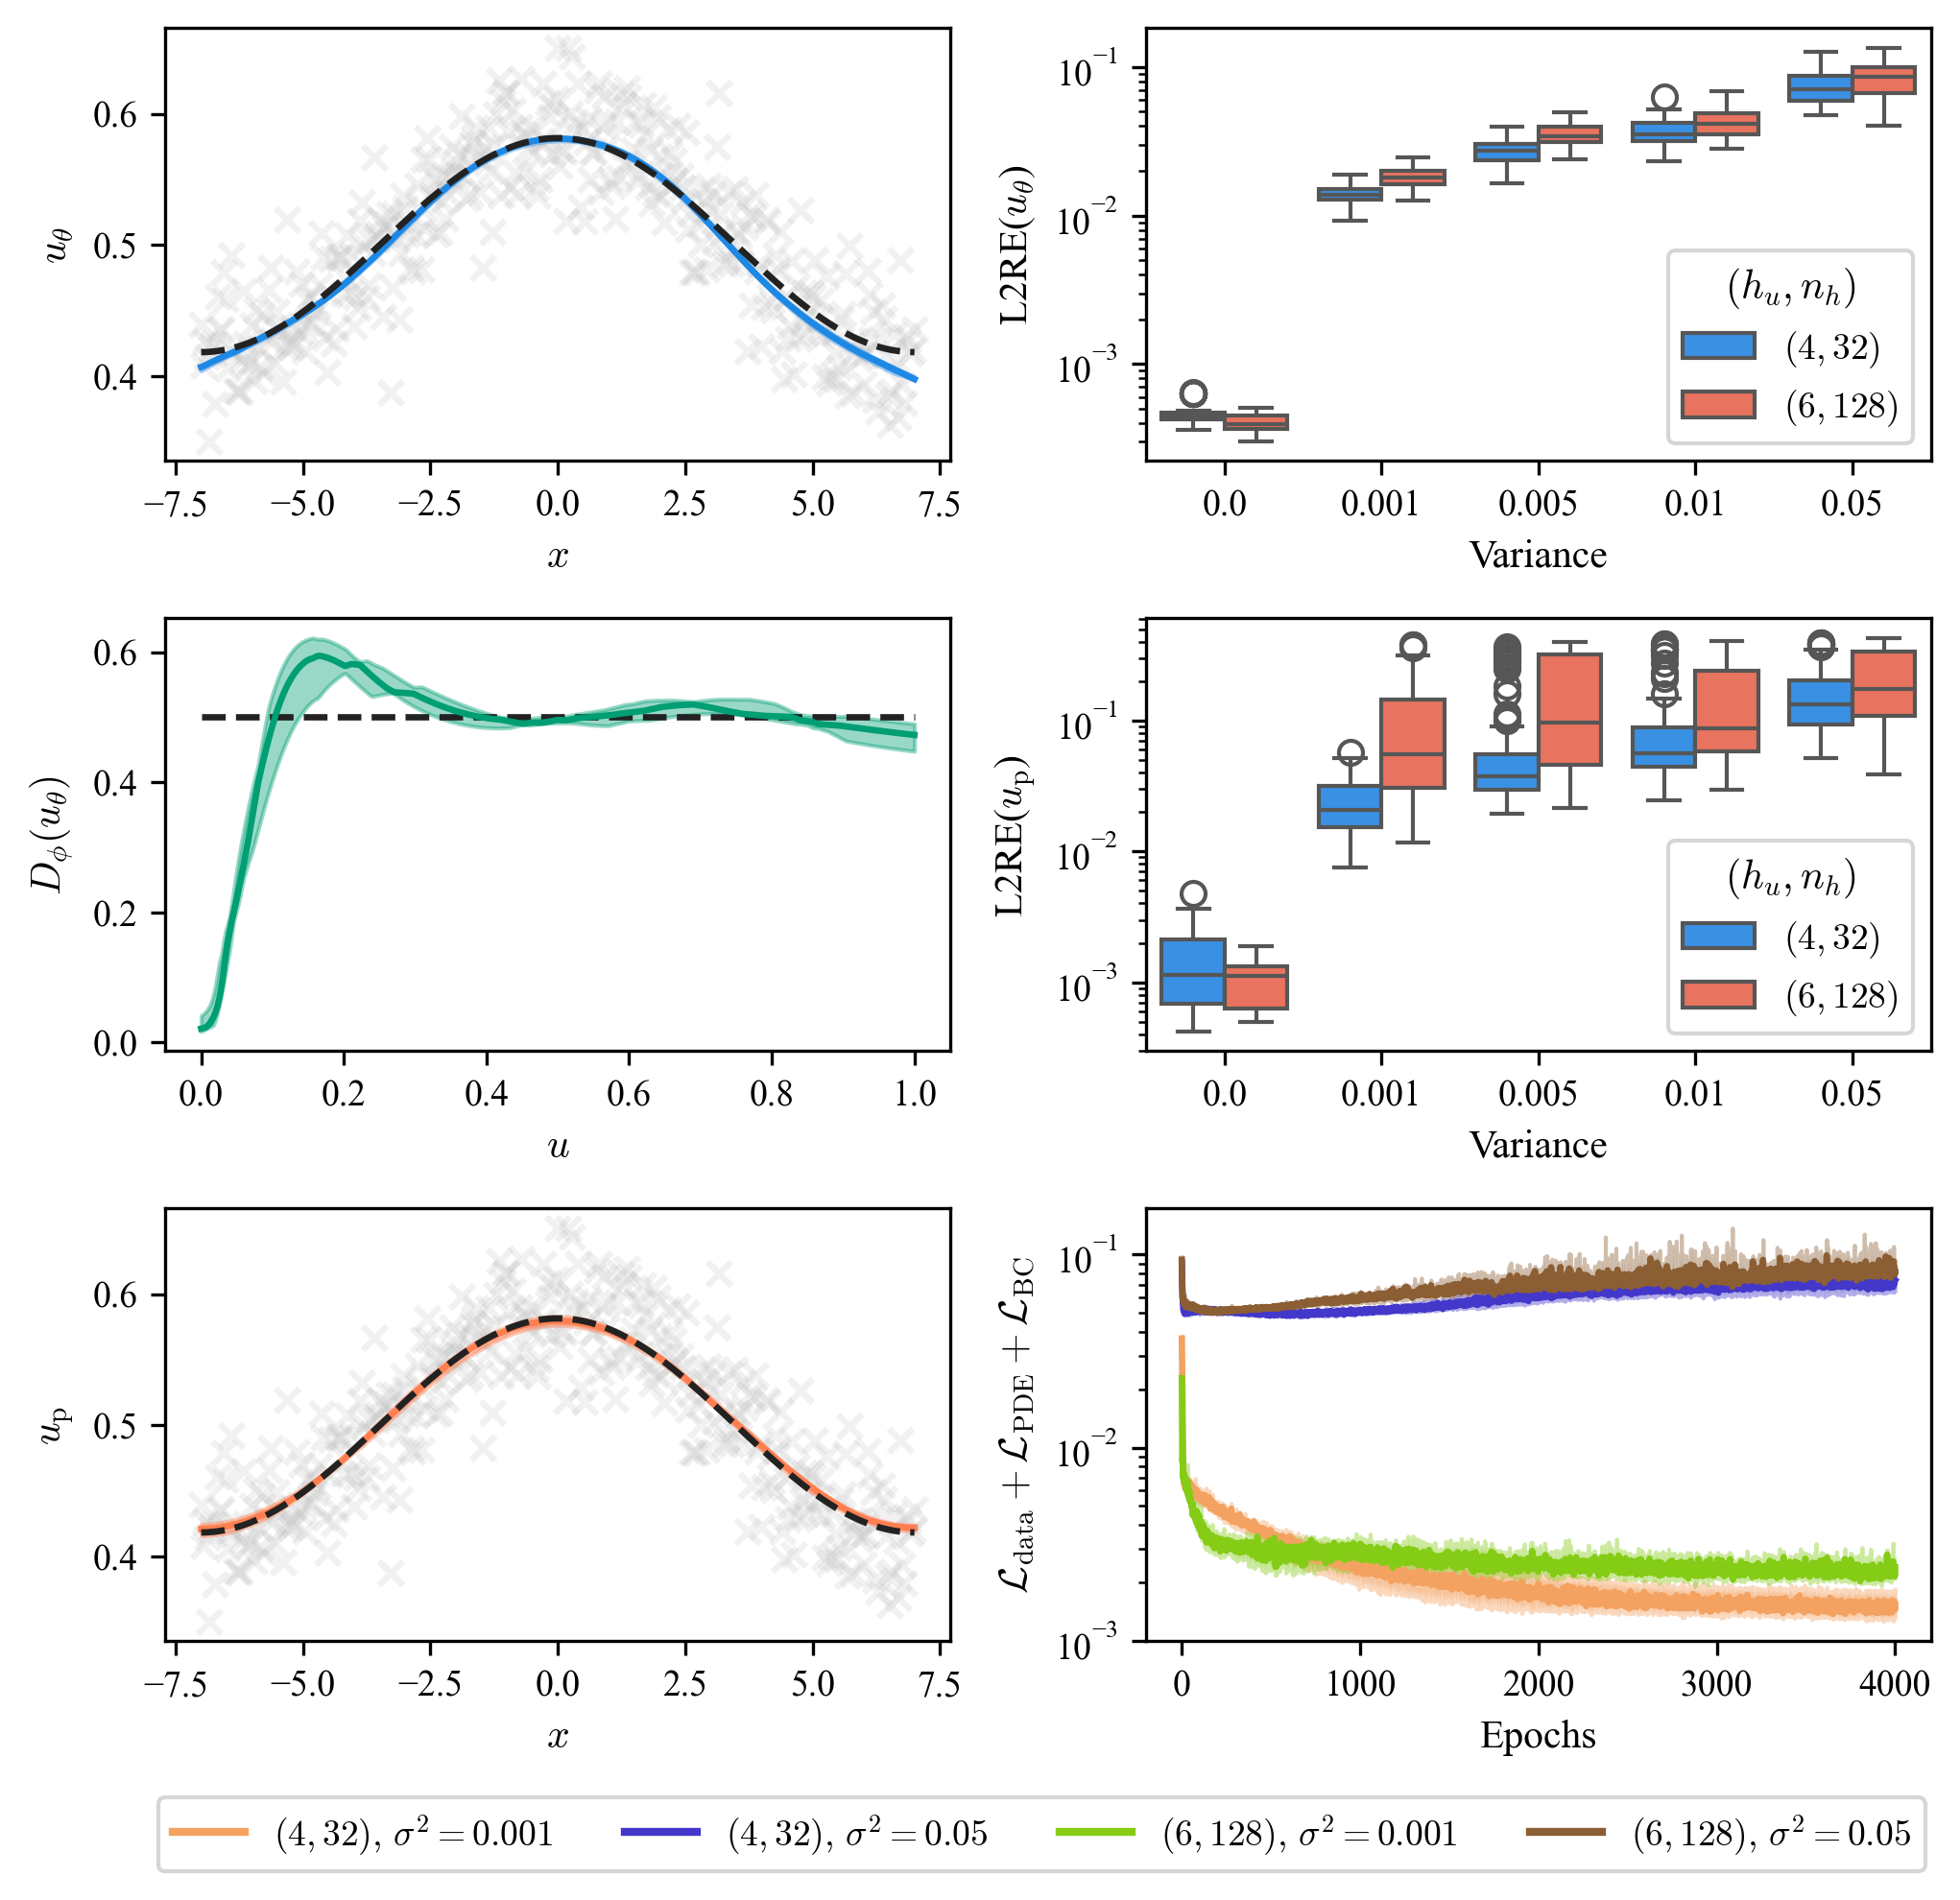

In [11]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

WIDTH = 6.92
HEIGHT = 4.2

def set_pubstyle(fontsize=10, usetex=False):
    plt.rcdefaults()
    plt.rcParams.update({
        "font.size": fontsize,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "CMU Serif", "Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize + 1,
        "legend.fontsize": fontsize - 1,
        "xtick.labelsize": fontsize - 1,
        "ytick.labelsize": fontsize - 1,
        "figure.titlesize": fontsize + 2,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "lines.linewidth": 1.6,
        "axes.linewidth": 0.8,
        "grid.alpha": 0.2,
    })
    if usetex:
        plt.rcParams.update({
            "text.usetex": True,
            "font.family": "serif",
        })

set_pubstyle(fontsize=10, usetex=False)

fig, ax = plt.subplots(3, 2, figsize=(WIDTH, 1.5*HEIGHT))

OBS = "#BDBDBD"       # observed data / u_o

OBS_EDGE = "#9E9E9E"

U_THETA = "#1E88E5"   # dodgerblue-ish

U_P = "#FF7F50"       # tomato-ish

TRUE = "#222222"  

D_COLOR = "#009E73"   # teal-green

colors = ['dodgerblue', 'tomato']

ax[0,0].scatter(x_train, u_data[tfinal, :], color=OBS, alpha=0.2, marker='x', label = r'$u_\mathrm{o}$')
ax[0,0].plot(x_train, u_learnt_median[tfinal, :], color=U_THETA, label = r'$u_\theta$')
ax[0,0].fill_between(x_train, u_learnt_25perc[tfinal, :], u_learnt_75perc[tfinal, :], color=U_THETA, alpha=0.4)
ax[0,0].plot(x_train, u_true[tfinal, :], '--', color=TRUE, label = r'$u$')
ax[0,0].set_xlabel(r'$x$')
ax[0,0].set_ylabel(r'$u_{\theta}$')
# ax[0,0].legend()

sns.boxplot(x='Variance', y=r'L2RE($u_{\theta}$)', hue=r'$(h_u, n_h)$', data=df, palette=colors, ax=ax[0,1])
ax[0,1].set_yscale('log')
# ax[0,1].set_ylim(1e-4, 1e0)
# ax[0,1].legend(loc='lower right')

ax[1,0].plot(U_grid, D_true * np.ones_like(U_grid), '--', color=TRUE, label=r'$D(u)=0.1$')
ax[1,0].plot(U_grid, D_learnt_median.flatten(), color=D_COLOR, label=r'$D_{\phi}(u_{\theta})$')
ax[1,0].fill_between(U_grid, D_learnt_25perc.flatten(), D_learnt_75perc.flatten(), color=D_COLOR, alpha=0.4)
ax[1,0].set_xlabel(r'$u$')
ax[1,0].set_ylabel(r'$D_{\phi}(u_{\theta})$')
# ax[1,0].legend()

sns.boxplot(x='Variance', y=r'L2RE($u_{\mathrm{p}}$)', hue=r'$(h_u, n_h)$', data=df1, palette=colors, ax=ax[1,1])
ax[1,1].set_yscale('log')
# ax[1,1].set_ylim(1e-4, 1e0)
# ax[1,1].legend(loc='lower right')

ax[2,0].scatter(x_train, u_data[tfinal, :], color=OBS, marker='x', alpha=0.2, label = r'$u_\mathrm{o}$')
ax[2,0].plot(x_train, u_pred_median[tfinal, :], color=U_P, label=r'$u_\mathrm{p}$')
ax[2,0].fill_between(x_train, u_pred_25perc[tfinal, :], u_pred_75perc[tfinal, :], color = U_P, alpha=0.4)
ax[2,0].plot(x_train, u_true[tfinal, :], '--', color=TRUE, label=r'$u$')
ax[2,0].set_xlabel(r'$x$')
ax[2,0].set_ylabel(r'$u_{\mathrm{p}}$')
# ax[2,0].legend()


BLUE = "#F4A261"

CORAL = "#84CC16"

TEAL = "#4338CA"

MAGENTA = "#8B5E34"

legends = [[r'$(4, 32),\, \sigma^2=0.001$', r'$(4, 32),\, \sigma^2=0.05$'], [r'$(6, 128),\, \sigma^2=0.001$', r'$(6, 128),\, \sigma^2=0.05$']]

colors2 =[[BLUE, TEAL], [CORAL, MAGENTA]]

for s, subfolder in enumerate(subfolders):
    for n, var in enumerate(variances_):
        # load loss_info
        val_pdeloss_S = np.load(top_load_folder + subfolder + f'var{var}/val_pdeloss_S.npy', allow_pickle=True)
        val_uloss_S = np.load(top_load_folder + subfolder + f'var{var}/val_uloss_S.npy', allow_pickle=True)
        val_BCloss_S = np.load(top_load_folder + subfolder + f'var{var}/val_BCloss_S.npy', allow_pickle=True)
        val_pdeloss_S, val_uloss_S, val_BCloss_S = np.asarray(val_pdeloss_S, dtype=float), np.asarray(val_uloss_S, dtype=float), np.asarray(val_BCloss_S, dtype=float)

        total_loss = val_uloss_S + val_BCloss_S + val_pdeloss_S
        median_total_loss = np.median(total_loss, axis=0)
        q1_total_loss = np.percentile(total_loss, 25, axis=0)
        q3_total_loss = np.percentile(total_loss, 75, axis=0)

        ax[2,1].plot(epoch_hist, median_total_loss, label=legends[s][n], color=colors2[s][n])
        ax[2,1].fill_between(epoch_hist, q1_total_loss, q3_total_loss, color=colors2[s][n], alpha=0.4)

ax[2,1].set_yscale('log')
ax[2,1].set_xlabel('Epochs')
ax[2,1].set_ylabel(r'$\mathcal{L}_{\mathrm{data}} + \mathcal{L}_{\mathrm{PDE}} + \mathcal{L}_{\mathrm{BC}}$')
# ax[2,1].legend(loc='best')
legend_handles = [
    Line2D([0], [0], color=colors2[0][0], lw=2, label=legends[0][0]),
    Line2D([0], [0], color=colors2[0][1], lw=2,  label=legends[0][1]),
    Line2D([0], [0], color=colors2[1][0], lw=2, label=legends[1][0]),
    Line2D([0], [0], color=colors2[1][1], lw=2,  label=legends[1][1])
]

fig.legend(
handles=legend_handles,
loc='lower center',
ncol=6,
frameon=True,
bbox_to_anchor=(0.53, -0.05)
)

plt.tight_layout()
fig.savefig(top_save_folder + f'fig2.svg', format='svg', bbox_inches='tight')
fig.savefig(top_save_folder + f'fig2.pdf', format='pdf', bbox_inches='tight')
plt.show()
